In [ ]:
import csv


data = [
    (1, "NB", "DB", "MB"),
    (2, "NB", "MB", "DB"),
    (3, "DB", "NB", "MB"),
    (4, "DB", "MB", "NB"),
    (5, "MB", "NB", "DB"),
    (6, "MB", "DB", "NB"),
    (7, "NB", "DB", "MB"),
    (8, "NB", "MB", "DB"),
    (9, "DB", "NB", "MB"),
    (10, "DB", "MB", "NB"),
    (11, "MB", "NB", "DB"),
    (12, "MB", "DB", "NB"),
    (13, "NB", "DB", "MB"),
    (14, "NB", "MB", "DB"),
    (15, "DB", "NB", "MB"),
]

# Write to CSV
with open("session_orders.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Participant", "Session 1", "Session 2", "Session 3"])
    writer.writerows(data)

print("CSV file 'session_orders.csv' created successfully.")


CSV file 'session_orders.csv' created successfully.


In [ ]:
import pandas as pd


file_path = "/content/Copy of Pre- Study-SSQ (Responses) - Form Responses 1 (2).csv"
ssq = pd.read_csv(file_path)


ssq.columns = ssq.columns.str.strip().str.replace("*", "", regex=False).str.replace("[", "", regex=False).str.replace("]", "", regex=False).str.strip()


severity_map = {"None": 0, "Slight": 1, "Moderate": 2, "Severe": 3}
symptom_columns = ssq.columns[4:]  # All symptom columns start from the 5th column
ssq[symptom_columns] = ssq[symptom_columns].applymap(severity_map.get)

# Step 3: Define symptoms under each SSQ category
nausea_symptoms = [
    "General discomfort",  "Salivation increasing", "Sweating",
    "Nausea", "Difficulty concentrating",
    "Stomach awareness", "Burping"
]

oculomotor_symptoms = [
    "General discomfort", "Headache", "Eye strain", "Difficulty focusing",
    "Difficulty concentrating", "Blurred vision", "Fatigue"
]

disorientation_symptoms = [
    "Difficulty focusing", "Nausea", "Blurred vision", "Dizziness with eyes open",
    "Dizziness with eyes closed", "Vertigo", "Fullness of the Head"
]

# Step 4: Calculate raw sub-scores
ssq['Nausea_raw'] = ssq[nausea_symptoms].sum(axis=1)
ssq['Oculomotor_raw'] = ssq[oculomotor_symptoms].sum(axis=1)
ssq['Disorientation_raw'] = ssq[disorientation_symptoms].sum(axis=1)

# Step 5: Apply scoring formula
ssq['Nausea'] = ssq['Nausea_raw'] * 9.54
ssq['Oculomotor'] = ssq['Oculomotor_raw'] * 7.58
ssq['Disorientation'] = ssq['Disorientation_raw'] * 13.92
ssq['Total'] = (ssq['Nausea_raw'] + ssq['Oculomotor_raw'] + ssq['Disorientation_raw']) * 3.74

# Step 6: Output results
ssq_scores = ssq[["Full Name", "Session", "Nausea", "Oculomotor", "Disorientation", "Total"]]
print(ssq_scores)




                Full Name  Session Nausea  Oculomotor  Disorientation  Total
0      A H M Nazmus Sakib        1  28.62       37.90           13.92  33.66
1      A H M Nazmus Sakib        2   9.54       22.74            0.00  14.96
2      A H M Nazmus Sakib        3   9.54       22.74            0.00  14.96
3             Guohao Yang        1    0.0        0.00            0.00    0.0
4             Guohao Yang        2  19.08        7.58           13.92  14.96
5             Guohao Yang        3  28.62       15.16           13.92  22.44
6        Christina Duthie        1    0.0        7.58            0.00   3.74
7        Christina Duthie        2    0.0        7.58           13.92   7.48
8        Christina Duthie        3    0.0        7.58           13.92   7.48
9          Anshu Tripathi        1    0.0        0.00            0.00    0.0
10         Anshu Tripathi        2  19.08       22.74           41.76  29.92
11         Anshu Tripathi        3  57.24       53.06           83.52  71.06

/tmp/ipython-input-3187259965.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ssq[symptom_columns] = ssq[symptom_columns].applymap(severity_map.get)


In [ ]:
import pandas as pd


orders = pd.read_csv("session_orders.csv")

seen = {}
participant_ids = []
current_id = 1

for name in ssq_scores["Full Name"]:
    name_key = name.lower()  # case-insensitive match
    if name_key not in seen:
        seen[name_key] = current_id
        current_id += 1
    participant_ids.append(seen[name_key])

ssq_scores["Participant"] = participant_ids


orders["Participant"] = orders["Participant"].astype(int)

# Function to safely get the condition
def get_condition(row):
    session_value = row["Session"]

    # Get session number from value
    if isinstance(session_value, str):
        session_num = int(session_value.strip()[-1])
    else:
        session_num = int(session_value)

    # Try to find match in orders
    if f"Session {session_num}" not in orders.columns:
        print(f"⚠ Missing column 'Session {session_num}' in orders.csv")
        return None

    match = orders.loc[orders["Participant"] == row["Participant"], f"Session {session_num}"]

    if match.empty:
        print(f"⚠ No match found for Participant {row['Participant']} in Session {session_num}")
        return None

    return match.values[0]

# Apply mapping
ssq_scores["Condition"] = ssq_scores.apply(get_condition, axis=1)

# Drop the Full Name column
ssq_scores.drop(columns=["Full Name"], inplace=True)
ssq_scores.to_csv("pre_ssq_scores.csv", index=False)
ssq_scores


/tmp/ipython-input-1892856083.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ssq_scores["Participant"] = participant_ids
/tmp/ipython-input-1892856083.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ssq_scores["Condition"] = ssq_scores.apply(get_condition, axis=1)
/tmp/ipython-input-1892856083.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

,Session,Nausea,Oculomotor,Disorientation,Total,Participant,Condition
0,1,28.62,37.90,13.92,33.66,1,NB
1,2,9.54,22.74,0.00,14.96,1,DB
2,3,9.54,22.74,0.00,14.96,1,MB
3,1,0.0,0.00,0.00,0.0,2,NB
4,2,19.08,7.58,13.92,14.96,2,MB
5,3,28.62,15.16,13.92,22.44,2,DB
6,1,0.0,7.58,0.00,3.74,3,DB
7,2,0.0,7.58,13.92,7.48,3,NB
8,3,0.0,7.58,13.92,7.48,3,MB
9,1,0.0,0.00,0.00,0.0,4,DB


In [ ]:
import pandas as pd

# Load the Post SSQ CSV and session order file
post_ssq_path = "/content/Copy of Post- Study-SSQ + IPQ  (Responses) - Form Responses 1 (2).csv"
session_order_path = "/content/session_orders.csv"

ssq = pd.read_csv(post_ssq_path)


ssq.columns = ssq.columns.str.strip().str.replace("*", "", regex=False).str.replace("[", "", regex=False).str.replace("]", "", regex=False).str.strip()


severity_map = {"None": 0, "Slight": 1, "Moderate": 2, "Severe": 3}
symptom_columns = ssq.columns[4:]  # All symptom columns start from the 5th column
ssq[symptom_columns] = ssq[symptom_columns].applymap(severity_map.get)

# Step 3: Define symptoms under each SSQ category
nausea_symptoms = [
    "General discomfort",  "Salivation increasing", "Sweating",
    "Nausea", "Difficulty concentrating",
    "Stomach awareness", "Burping"
]

oculomotor_symptoms = [
    "General discomfort", "Headache", "Eye strain", "Difficulty focusing",
    "Difficulty concentrating", "Blurred vision", "Fatigue"
]

disorientation_symptoms = [
    "Difficulty focusing", "Nausea", "Blurred vision", "Dizziness with eyes open",
    "Dizziness with eyes closed", "Vertigo", "Fullness of the Head"
]

# Step 4: Calculate raw sub-scores
ssq['Nausea_raw'] = ssq[nausea_symptoms].sum(axis=1)
ssq['Oculomotor_raw'] = ssq[oculomotor_symptoms].sum(axis=1)
ssq['Disorientation_raw'] = ssq[disorientation_symptoms].sum(axis=1)

# Step 5: Apply scoring formula
ssq['Nausea'] = ssq['Nausea_raw'] * 9.54
ssq['Oculomotor'] = ssq['Oculomotor_raw'] * 7.58
ssq['Disorientation'] = ssq['Disorientation_raw'] * 13.92
ssq['Total'] = (ssq['Nausea_raw'] + ssq['Oculomotor_raw'] + ssq['Disorientation_raw']) * 3.74

# Step 6: Output results
ssq_scores = ssq[["Name", "Session", "Nausea", "Oculomotor", "Disorientation", "Total"]]
print(ssq_scores)


                     Name  Session  Nausea  Oculomotor  Disorientation   Total
0      A H M Nazmus Sakib        1   57.24       37.90           27.84   48.62
1      A H M Nazmus Sakib        2   19.08       22.74           13.92   22.44
2      A H M Nazmus Sakib        3   28.62       30.32           27.84   33.66
3             Guohao Yang        1   38.16       30.32           55.68   44.88
4             Guohao Yang        2   57.24       45.48           55.68   59.84
5             Guohao Yang        3   47.70       53.06           55.68   59.84
6        Christina Duthie        1    0.00       22.74           27.84   18.70
7        Christina Duthie        2    0.00       22.74           41.76   22.44
8        Christina Duthie        3    0.00        7.58           13.92    7.48
9          Anshu Tripathi        1   47.70       60.64           55.68   63.58
10         Anshu Tripathi        2   66.78       75.80          111.36   93.50
11         Anshu Tripathi        3   95.40       90.

/tmp/ipython-input-60520452.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ssq[symptom_columns] = ssq[symptom_columns].applymap(severity_map.get)


In [ ]:
seen = {}
participant_ids = []
current_id = 1

for name in ssq_scores["Name"]:
    # Normalize: lowercase + collapse multiple spaces
    name_key = " ".join(name.lower().split())
    if name_key not in seen:
        seen[name_key] = current_id
        current_id += 1
    participant_ids.append(seen[name_key])

ssq_scores["Participant"] = participant_ids

orders["Participant"] = orders["Participant"].astype(int)

# Function to safely get the condition
def get_condition(row):
    session_value = row["Session"]

    # Get session number from value
    if isinstance(session_value, str):
        session_num = int(session_value.strip()[-1])
    else:
        session_num = int(session_value)

    # Check if session column exists
    if f"Session {session_num}" not in orders.columns:
        print(f"⚠ Missing column 'Session {session_num}' in orders.csv")
        return None

    match = orders.loc[orders["Participant"] == row["Participant"], f"Session {session_num}"]

    if match.empty:
        print(f"⚠ No match found for Participant {row['Participant']} in Session {session_num}")
        return None

    return match.values[0]

# Apply mapping
ssq_scores["Condition"] = ssq_scores.apply(get_condition, axis=1)

# Save and clean
ssq_scores.to_csv("post_ssq_scores.csv", index=False)
ssq_scores.drop(columns=["Name"], inplace=True)
ssq_scores

/tmp/ipython-input-1298874916.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ssq_scores["Participant"] = participant_ids
/tmp/ipython-input-1298874916.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ssq_scores["Condition"] = ssq_scores.apply(get_condition, axis=1)
/tmp/ipython-input-1298874916.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

,Session,Nausea,Oculomotor,Disorientation,Total,Participant,Condition
0,1,57.24,37.90,27.84,48.62,1,NB
1,2,19.08,22.74,13.92,22.44,1,DB
2,3,28.62,30.32,27.84,33.66,1,MB
3,1,38.16,30.32,55.68,44.88,2,NB
4,2,57.24,45.48,55.68,59.84,2,MB
5,3,47.70,53.06,55.68,59.84,2,DB
6,1,0.00,22.74,27.84,18.70,3,DB
7,2,0.00,22.74,41.76,22.44,3,NB
8,3,0.00,7.58,13.92,7.48,3,MB
9,1,47.70,60.64,55.68,63.58,4,DB


KSU data

In [ ]:
nb=pd.read_csv('/content/NB Pre- Study-SSQ(KSU) (Responses) - Form Responses 1.csv')
nb['Condition']='NB'
db=pd.read_csv('/content/DB Pre- Study-SSQ(KSU) (Responses) - Form Responses 1.csv')
db['Condition']='DB'
mb=pd.read_csv('/content/MB Pre- Study-SSQ(KSU) (Responses) - Form Responses 1.csv')
mb['Condition']='MB'
pre_ssq=pd.concat([nb,db,mb],axis=0)
pre_ssq

,Timestamp,Full Name,Date,Session,[General discomfort],[Fatigue],[Headache],[Eye strain],[Difficulty focusing],[Salivation increasing],...,[Nausea],[Difficulty concentrating],[*Fullness of the Head],[Blurred vision],[Dizziness with eyes open],[Dizziness with eyes closed],[** Vertigo],[*** Stomach awareness],[Burping],Condition
0,5/6/2025 15:28,Syeda Umme Salma,9/19/1999,1,NaN,NaN,Moderate,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NB
1,5/8/2025 11:53,Sharar Naiarin Haque,5/8/2025,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NB
2,5/14/2025 14:17,Md Majedul Islam,10/13/1995,3,NaN,NaN,Slight,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NB
3,5/14/2025 15:21,Kazi Fahim Ahmad Nasif,5/14/2025,2,NaN,NaN,Slight,NaN,Slight,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NB
4,5/26/2025 14:42,Ambar Conde,5/26/2025,2,NaN,NaN,Slight,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,7/15/2025 15:33,Jeffrey Davis,10/3/2000,3,NaN,NaN,Slight,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB
16,7/22/2025 14:04,Hasim Oz,1/23/1995,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB
17,7/23/2025 14:50,Rohan Jonnalagadda,7/23/2025,3,Moderate,Slight,Slight,Moderate,Slight,Slight,...,Slight,Slight,Moderate,Slight,NaN,NaN,NaN,NaN,NaN,MB
18,7/25/2025 11:14,Eymen Yigit,9/6/2001,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB


In [ ]:
import pandas as pd
import numpy as np

# --- Step 0: Load raw data ---
nb = pd.read_csv('/content/NB Pre- Study-SSQ(KSU) (Responses) - Form Responses 1.csv')
nb['Condition'] = 'NB'

db = pd.read_csv('/content/DB Pre- Study-SSQ(KSU) (Responses) - Form Responses 1.csv')
db['Condition'] = 'DB'

mb = pd.read_csv('/content/MB Pre- Study-SSQ(KSU) (Responses) - Form Responses 1.csv')
mb['Condition'] = 'MB'


pre_ssq = pd.concat([nb, db, mb], axis=0).reset_index(drop=True)
pre_ssq['Timestamp'] = pd.to_datetime(pre_ssq['Timestamp'], errors='coerce')
pre_ssq = pre_ssq.sort_values(by="Timestamp", kind="stable").reset_index(drop=True)

ssq = pre_ssq.copy()


ssq.columns = (
    ssq.columns
    .str.strip()
    .str.replace("*", "", regex=False)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.strip()
)


severity_map = {"None": 0, "Slight": 1, "Moderate": 2, "Severe": 3}

symptom_columns = [col for col in ssq.columns[4:] if col not in ['Condition']]
ssq[symptom_columns] = ssq[symptom_columns].applymap(severity_map.get)


nausea_symptoms = [
    "General discomfort", "Salivation increasing", "Sweating",
    "Nausea", "Difficulty concentrating", "Stomach awareness", "Burping"
]

oculomotor_symptoms = [
    "General discomfort", "Headache", "Eye strain", "Difficulty focusing",
    "Difficulty concentrating", "Blurred vision", "Fatigue"
]

disorientation_symptoms = [
    "Difficulty focusing", "Nausea", "Blurred vision", "Dizziness with eyes open",
    "Dizziness with eyes closed", "Vertigo", "Fullness of the Head"
]


ssq['Nausea_raw'] = ssq[nausea_symptoms].sum(axis=1)
ssq['Oculomotor_raw'] = ssq[oculomotor_symptoms].sum(axis=1)
ssq['Disorientation_raw'] = ssq[disorientation_symptoms].sum(axis=1)


ssq['Nausea'] = ssq['Nausea_raw'] * 9.54
ssq['Oculomotor'] = ssq['Oculomotor_raw'] * 7.58
ssq['Disorientation'] = ssq['Disorientation_raw'] * 13.92
ssq['Total'] = (ssq['Nausea_raw'] + ssq['Oculomotor_raw'] + ssq['Disorientation_raw']) * 3.74


seen = {}
participant_ids = []
current_id = 16

for name in ssq['Full Name']:
    if pd.isna(name):
        participant_ids.append(np.nan)
        continue
    # Normalize name: lowercase + collapse spaces
    name_key = " ".join(str(name).lower().split())
    if name_key not in seen:
        seen[name_key] = current_id
        current_id += 1
    participant_ids.append(seen[name_key])

ssq['Participant'] = participant_ids


ssq_scores = ssq[[
    "Full Name", "Session", "Nausea", "Oculomotor",
    "Disorientation", "Total", "Condition", "Participant"
]].copy()

# --- Step 7: Sort so participants stay together, session order preserved ---
ssq_scores = ssq_scores.sort_values(
    by=["Participant", "Session"], kind="stable"
).reset_index(drop=True)

# --- Done: inspect or save ---
# ssq_scores.to_csv("ssq_scores_processed.csv", index=False)
ssq_scores.drop(columns=["Full Name"], inplace=True)
ssq_scores.to_csv("pre_ssq_scores_ksu.csv", index=False)
ssq_scores


/tmp/ipython-input-613104215.py:35: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ssq[symptom_columns] = ssq[symptom_columns].applymap(severity_map.get)


,Session,Nausea,Oculomotor,Disorientation,Total,Condition,Participant
0,1,0.00,15.16,0.00,7.48,NB,16
1,2,28.62,45.48,27.84,41.14,DB,16
2,1,0.00,0.00,0.00,0.00,NB,17
3,2,0.00,0.00,0.00,0.00,MB,17
4,3,0.00,0.00,0.00,0.00,DB,17
...,...,...,...,...,...,...,...
61,2,0.00,0.00,0.00,0.00,MB,37
62,3,0.00,7.58,0.00,3.74,NB,37
63,1,9.54,0.00,13.92,7.48,MB,38
64,2,28.62,7.58,27.84,22.44,NB,38


In [ ]:
ssq_scores.Participant

,Participant
0,16
1,16
2,17
3,17
4,17
...,...
61,38
62,38
63,38
64,39


In [ ]:
import pandas as pd
import numpy as np

# --- Step 0: Load post-study SSQ CSVs ---
nb = pd.read_csv('/content/NB Post- Study-SSQ + IPQ(KSU)  (Responses) - Form Responses 1 (2).csv')
db = pd.read_csv('/content/DB Post- Study-SSQ + IPQ(KSU)  (Responses) - Form Responses 1 (1).csv')
mb = pd.read_csv('/content/MB Post- Study-SSQ + IPQ(KSU)  (Responses) - Form Responses 1 (1).csv')

# Assign Condition
nb['Condition'] = 'NB'
db['Condition'] = 'DB'
mb['Condition'] = 'MB'

# Concatenate all
post_ssq = pd.concat([nb, db, mb], axis=0).reset_index(drop=True)
post_ssq['Timestamp'] = pd.to_datetime(post_ssq['Timestamp'], errors='coerce')
post_ssq = post_ssq.sort_values(by="Timestamp", kind="stable").reset_index(drop=True)
# --- Step 1: Copy and clean data ---
ssq = post_ssq.copy()

ssq.columns = (
    ssq.columns
    .str.strip()
    .str.replace("*", "", regex=False)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.strip()
)


severity_map = {"None": 0, "Slight": 1, "Moderate": 2, "Severe": 3}
# Assuming symptom columns start from 5th column and exclude 'Condition' if present at the end
symptom_columns = [col for col in ssq.columns[4:] if col not in ['Condition']]
ssq[symptom_columns] = ssq[symptom_columns].applymap(severity_map.get)

# --- Step 2: Define SSQ categories ---
nausea_symptoms = [
    "General discomfort", "Salivation increasing", "Sweating",
    "Nausea", "Difficulty concentrating", "Stomach awareness", "Burping"
]

oculomotor_symptoms = [
    "General discomfort", "Headache", "Eye strain", "Difficulty focusing",
    "Difficulty concentrating", "Blurred vision", "Fatigue"
]

disorientation_symptoms = [
    "Difficulty focusing", "Nausea", "Blurred vision", "Dizziness with eyes open",
    "Dizziness with eyes closed", "Vertigo", "Fullness of the Head"
]

# --- Step 3: Calculate raw scores ---
ssq['Nausea_raw'] = ssq[nausea_symptoms].sum(axis=1)
ssq['Oculomotor_raw'] = ssq[oculomotor_symptoms].sum(axis=1)
ssq['Disorientation_raw'] = ssq[disorientation_symptoms].sum(axis=1)

# --- Step 4: Apply SSQ scoring formula ---
ssq['Nausea'] = ssq['Nausea_raw'] * 9.54
ssq['Oculomotor'] = ssq['Oculomotor_raw'] * 7.58
ssq['Disorientation'] = ssq['Disorientation_raw'] * 13.92
ssq['Total'] = (ssq['Nausea_raw'] + ssq['Oculomotor_raw'] + ssq['Disorientation_raw']) * 3.74

# --- Step 5: Assign Participant IDs starting from 16 ---
seen = {}
participant_ids = []
current_id = 16

for name in ssq['Name']:
    if pd.isna(name):
        participant_ids.append(np.nan)
        continue

    name_key = " ".join(str(name).lower().split())
    if name_key not in seen:
        seen[name_key] = current_id
        current_id += 1
    participant_ids.append(seen[name_key])

ssq['Participant'] = participant_ids

# --- Step 6: Keep only relevant columns ---
ssq_scores = ssq[[
    "Name", "Session", "Nausea", "Oculomotor",
    "Disorientation", "Total", "Condition", "Participant"
]].copy()

# --- Step 7: Sort participants together (session order preserved) ---
ssq_scores = ssq_scores.sort_values(
    by=["Participant"], kind="stable"
).reset_index(drop=True)

# --- Step 8: Save results ---
ssq_scores.drop(columns=["Name"], inplace=True)
ssq_scores.to_csv("post_ssq_scores_ksu.csv", index=False)


ssq_scores


/tmp/ipython-input-2392898971.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ssq[symptom_columns] = ssq[symptom_columns].applymap(severity_map.get)


,Session,Nausea,Oculomotor,Disorientation,Total,Condition,Participant
0,1,38.16,45.48,41.76,48.62,NB,16
1,2,19.08,68.22,55.68,56.10,DB,16
2,2,19.08,15.16,55.68,29.92,NB,17
3,2,9.54,15.16,41.76,22.44,MB,17
4,3,114.48,30.32,111.36,89.76,DB,17
...,...,...,...,...,...,...,...
60,2,0.00,7.58,0.00,3.74,MB,37
61,3,9.54,7.58,0.00,7.48,NB,37
62,1,9.54,15.16,13.92,14.96,MB,38
63,2,19.08,7.58,27.84,18.70,NB,38


In [ ]:
post_ssq['Timestamp'] = pd.to_datetime(post_ssq['Timestamp'], errors='coerce')
post_ssq = post_ssq.sort_values(by="Timestamp", kind="stable").reset_index(drop=True)
post_ssq

,Timestamp,Name,Session,"How aware were you of the real world surrounding you while navigating in the virtual world? (i.e. sounds, room temperature, other people, etc.)?",How real did the virtual world seem to you?,"I had a sense of acting in the virtual space, rather than operating something from outside.",How much did your experience in the virtual environment seem consistent with your real-world experience?,How real did the virtual world seem to you?.1,I did not feel present in the virtual space.,I was not aware of my real environment.,...,\nI found the system unnecessarily complex.,\nI thought the system was easy to use.,I think that I would need the support of a technical person to be able to use this system.,\nI found the various functions in this system were well integrated.,I thought there was too much inconsistency in this system.,I would imagine that most people would learn to use this system very quickly.,I found the system very cumbersome to use.,I felt very confident using the system.,I needed to learn a lot of things before I could get going with this system.,Condition
0,2025-05-06 15:45:39,Syeda Umme Salma,1,1,3,3,4,2.0,4,1,...,1,5,1,5,1,3,2,2,1,NB
1,2025-05-06 16:06:21,Syeda Umme Salma,2,1,3,4,2,4.0,2,1,...,2,5,3,4,2,5,1,4,1,DB
2,2025-05-08 12:18:45,Sharar Naiarin Haque,2,3,2,5,5,4.0,5,5,...,1,5,1,5,1,5,1,5,2,NB
3,2025-05-08 12:32:23,Sharar Naiarin Haque,2,1,5,4,2,5.0,5,4,...,1,5,1,5,1,5,1,5,2,MB
4,2025-05-08 13:03:08,Sharar Naiarin Haque,3,6,2,5,5,1.0,5,5,...,1,5,1,5,1,5,1,5,2,DB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,2025-07-25 11:21:22,Eymen Yigit,2,5,4,2,3,1.0,2,2,...,1,5,1,4,1,5,1,4,1,MB
61,2025-07-25 11:29:38,Eymen Yigit,3,4,3,4,3,3.0,4,3,...,1,4,1,4,1,5,1,4,1,NB
62,2025-07-25 16:08:09,Maddison Duda,1,4,3,5,4,2.0,1,2,...,2,4,1,4,4,2,2,4,4,MB
63,2025-07-25 16:19:13,Maddison Duda,2,2,4,3,2,1.0,3,2,...,3,4,1,3,2,2,2,4,2,NB


In [ ]:
import pandas as pd
import numpy as np

seen = {}
participant_ids = []
current_id = 16  # start from your desired number

for name in ssq_scores["Name"]:
    # Skip missing names
    if pd.isna(name):
        participant_ids.append(np.nan)  # keep as NaN
        continue

    # Normalize: lowercase + collapse multiple spaces
    name_key = " ".join(str(name).lower().split())
    if name_key not in seen:
        seen[name_key] = current_id
        current_id += 1
    participant_ids.append(seen[name_key])

ssq_scores["Participant"] = participant_ids
orders["Participant"] = orders["Participant"].astype(int)

# Sort so same participants stay together
ssq_scores = ssq_scores.sort_values(by=["Participant", "Session"]).reset_index(drop=True)

# Function to safely get the condition
def get_condition(row):
    session_value = row["Session"]

    if isinstance(session_value, str):
        session_num = int(session_value.strip()[-1])
    else:
        session_num = int(session_value)

    if f"Session {session_num}" not in orders.columns:
        print(f"⚠ Missing column 'Session {session_num}' in orders.csv")
        return None

    match = orders.loc[orders["Participant"] == row["Participant"], f"Session {session_num}"]

    if match.empty:
        print(f"⚠ No match found for Participant {row['Participant']} in Session {session_num}")
        return None

    return match.values[0]

# Apply mapping
ssq_scores["Condition"] = ssq_scores.apply(get_condition, axis=1)

# Drop Name column
ssq_scores.drop(columns=["Name"], inplace=True)
# ssq_scores.to_csv("post_ssq_scores_ksu.csv", index=False)
ssq_scores

/tmp/ipython-input-1486262316.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ssq_scores["Participant"] = participant_ids


⚠ No match found for Participant 16.0 in Session 1
⚠ No match found for Participant 16.0 in Session 2
⚠ No match found for Participant 17.0 in Session 2
⚠ No match found for Participant 17.0 in Session 2
⚠ No match found for Participant 17.0 in Session 3
⚠ No match found for Participant 18.0 in Session 1
⚠ No match found for Participant 18.0 in Session 2
⚠ No match found for Participant 18.0 in Session 3
⚠ No match found for Participant 19.0 in Session 1
⚠ No match found for Participant 19.0 in Session 2
⚠ No match found for Participant 19.0 in Session 3
⚠ No match found for Participant 20.0 in Session 1
⚠ No match found for Participant 20.0 in Session 2
⚠ No match found for Participant 20.0 in Session 3
⚠ No match found for Participant 21.0 in Session 1
⚠ No match found for Participant 21.0 in Session 2
⚠ No match found for Participant 21.0 in Session 3
⚠ No match found for Participant 22.0 in Session 1
⚠ No match found for Participant 22.0 in Session 2
⚠ No match found for Participan

,Session,Nausea,Oculomotor,Disorientation,Total,Participant,Condition
0,1,0.0,0.0,0.0,0.0,16.0,None
1,2,0.0,0.0,0.0,0.0,16.0,None
2,2,0.0,0.0,0.0,0.0,17.0,None
3,2,0.0,0.0,0.0,0.0,17.0,None
4,3,0.0,0.0,0.0,0.0,17.0,None
...,...,...,...,...,...,...,...
60,3,0.0,0.0,0.0,0.0,36.0,None
61,1,0.0,0.0,0.0,0.0,37.0,None
62,1,0.0,0.0,0.0,0.0,38.0,None
63,2,0.0,0.0,0.0,0.0,38.0,None


In [ ]:
ssq_scores.Name.isna().sum()

np.int64(1)

In [ ]:
!cp /content/post_ssq_scores_ksu.csv '/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/'
!cp '/content/pre_ssq_scores_ksu.csv' '/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/'
!cp '/content/pre_ssq_scores.csv' '/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/'
!cp '/content/post_ssq_scores.csv' '/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/'


Analysis

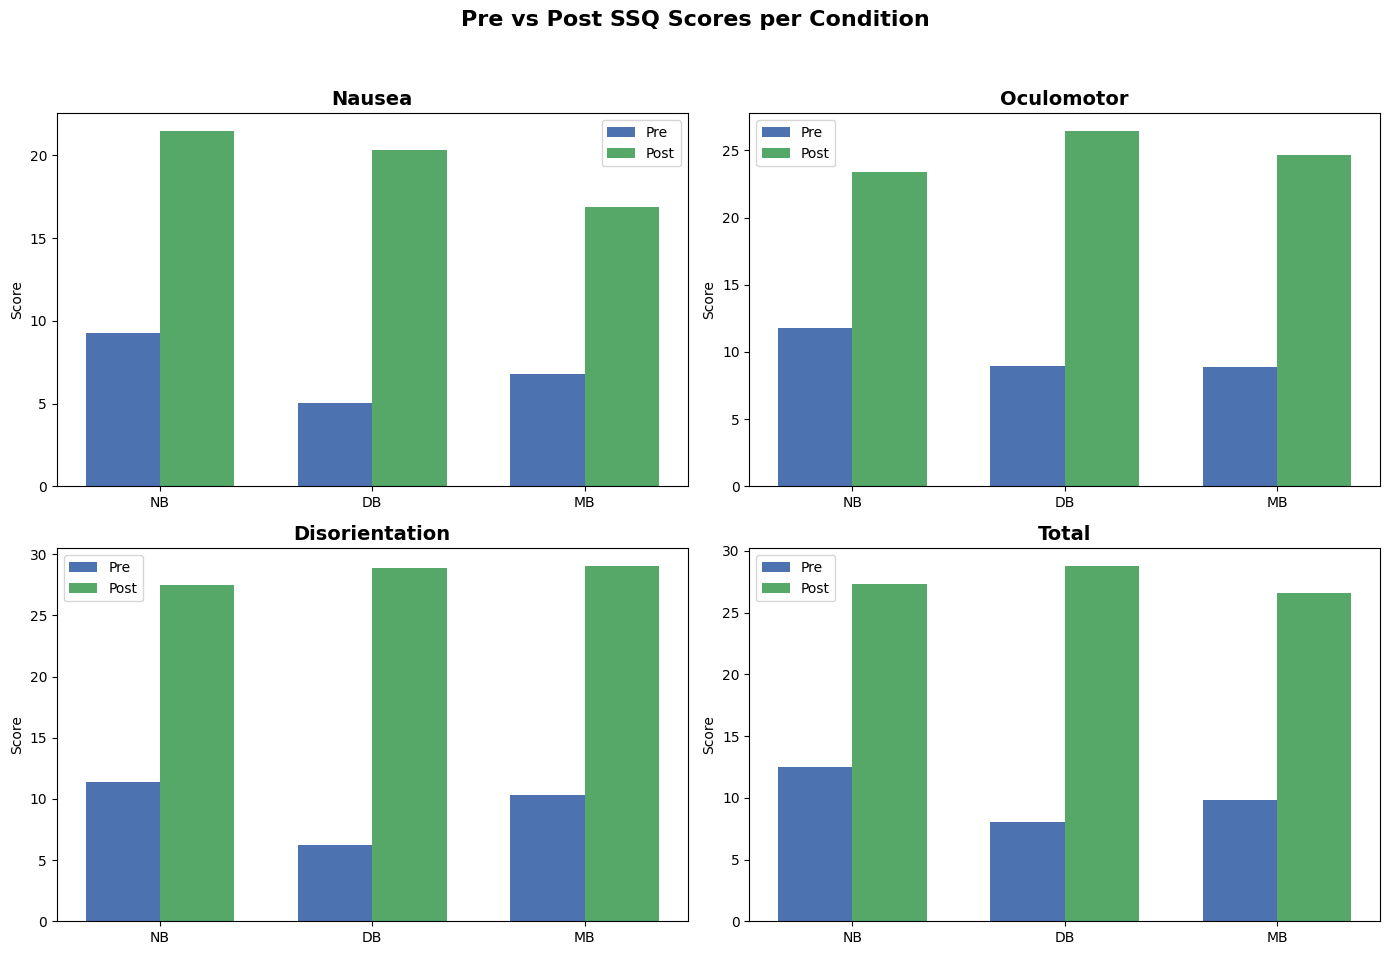

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
pre_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3//pre_ssq_scores.csv")
post_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3//post_ssq_scores.csv")
pre_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3//pre_ssq_scores_ksu.csv")
post_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3//post_ssq_scores_ksu.csv")
pre_df = pd.concat([pre_df1, pre_df2], axis=0)
post_df = pd.concat([post_df1, post_df2], axis=0)

# Desired condition order
condition_order = ["NB", "DB", "MB"]


pre_grouped = pre_df.groupby("Condition")[["Nausea", "Oculomotor", "Disorientation", "Total"]].mean().loc[condition_order]
post_grouped = post_df.groupby("Condition")[["Nausea", "Oculomotor", "Disorientation", "Total"]].mean().loc[condition_order]

# Plot setup
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Pre vs Post SSQ Scores per Condition", fontsize=16, fontweight='bold')

metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]
axes = axs.ravel()

x = np.arange(len(condition_order))  # numeric x positions
bar_width = 0.35

# Plot each metric
for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.bar(x - bar_width/2, pre_grouped[metric], width=bar_width, label='Pre', color='#4c72b0')
    ax.bar(x + bar_width/2, post_grouped[metric], width=bar_width, label='Post', color='#55a868')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(condition_order)
    ax.legend()


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
print("=== Pre SSQ ===")
for cond in condition_order:
    subset = pre_df[pre_df["Condition"] == cond]
    print(f"\nCondition: {cond}")
    for metric in metrics:
        mean_val = subset[metric].mean()
        std_val = subset[metric].std()
        print(f"{metric}: mean = {mean_val:.2f}, std = {std_val:.2f}")

print("\n=== Post SSQ ===")
for cond in condition_order:
    subset = post_df[post_df["Condition"] == cond]
    print(f"\nCondition: {cond}")
    for metric in metrics:
        mean_val = subset[metric].mean()
        std_val = subset[metric].std()
        print(f"{metric}: mean = {mean_val:.2f}, std = {std_val:.2f}")

=== Pre SSQ ===

Condition: NB
Nausea: mean = 9.29, std = 17.39
Oculomotor: mean = 11.77, std = 16.03
Disorientation: mean = 11.36, std = 23.08
Total: mean = 12.50, std = 18.94

Condition: DB
Nausea: mean = 5.02, std = 8.80
Oculomotor: mean = 8.98, std = 10.10
Disorientation: mean = 6.23, std = 10.59
Total: mean = 8.07, std = 9.90

Condition: MB
Nausea: mean = 6.81, std = 13.41
Oculomotor: mean = 8.88, std = 15.21
Disorientation: mean = 10.34, std = 20.07
Total: mean = 9.83, std = 17.36

=== Post SSQ ===

Condition: NB
Nausea: mean = 21.46, std = 28.97
Oculomotor: mean = 23.37, std = 21.39
Disorientation: mean = 27.45, std = 32.69
Total: mean = 27.32, std = 28.27

Condition: DB
Nausea: mean = 20.30, std = 27.00
Oculomotor: mean = 26.43, std = 22.80
Disorientation: mean = 28.91, std = 32.00
Total: mean = 28.77, std = 27.03

Condition: MB
Nausea: mean = 16.90, std = 23.61
Oculomotor: mean = 24.69, std = 26.15
Disorientation: mean = 29.03, std = 38.40
Total: mean = 26.61, std = 31.35


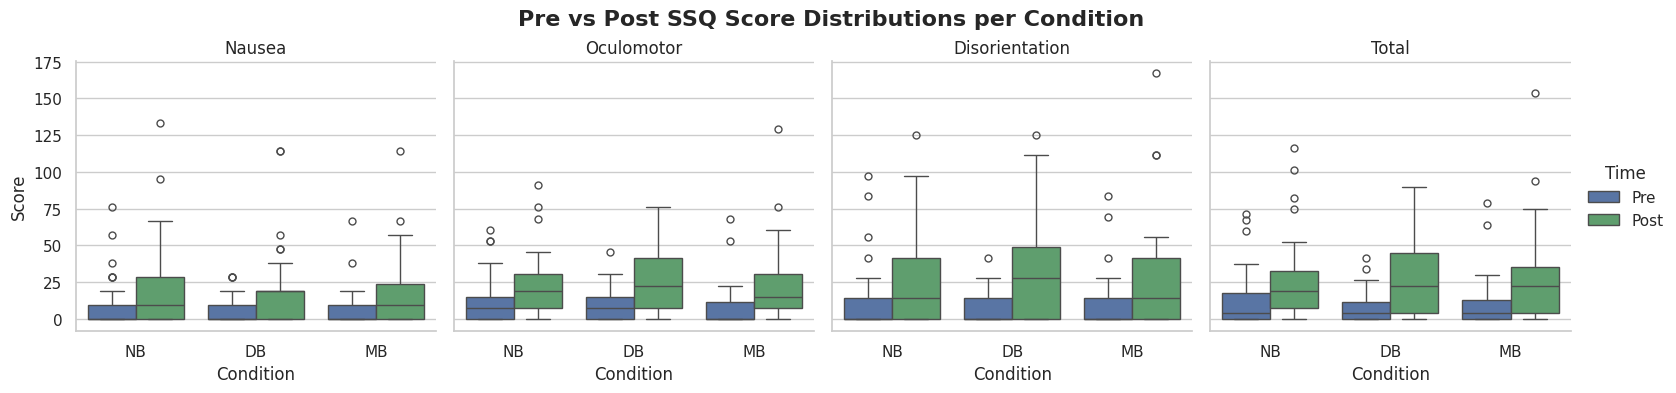

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


pre_df["Time"] = "Pre"
post_df["Time"] = "Post"


combined_df = pd.concat([pre_df, post_df], ignore_index=True)


melted_df = pd.melt(
    combined_df,
    id_vars=["Condition", "Time"],
    value_vars=["Nausea", "Oculomotor", "Disorientation", "Total"],
    var_name="Metric",
    value_name="Score"
)

# Plotting style
sns.set(style="whitegrid")

# Create boxplots per metric
g = sns.catplot(
    data=melted_df,
    kind="box",
    x="Condition", y="Score",
    hue="Time",
    col="Metric",
    palette=["#4c72b0", "#55a868"],
    height=4, aspect=1
)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Pre vs Post SSQ Score Distributions per Condition", fontsize=16, fontweight='bold')
g.set_titles("{col_name}")
g.set_axis_labels("Condition", "Score")
plt.show()

In [ ]:

merged = pd.merge(pre_df, post_df, on=["Participant", "Condition"], suffixes=("_pre", "_post"))

for metric in ["Nausea", "Oculomotor", "Disorientation", "Total"]:
    merged[f"{metric}_change"] = merged[f"{metric}_post"] - merged[f"{metric}_pre"]
import scipy.stats as stats

# One-way ANOVA for each metric
for metric in ["Nausea", "Oculomotor", "Disorientation", "Total"]:
    print(f"\nANOVA for {metric} Change:")
    groups = [group[metric + "_change"].values for name, group in merged.groupby("Condition")]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"F = {f_stat:.4f}, p = {p_val:.4f}")



ANOVA for Nausea Change:
F = 0.6470, p = 0.5256

ANOVA for Oculomotor Change:
F = 1.1139, p = 0.3321

ANOVA for Disorientation Change:
F = 0.5035, p = 0.6058

ANOVA for Total Change:
F = 0.7469, p = 0.4763


In [ ]:
import pandas as pd
from scipy.stats import kruskal
!pip install scikit_posthocs
import scikit_posthocs as sp_posthocs


metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]
condition_order = ["NB", "DB", "MB"]

print("=== Kruskal–Wallis Test Results ===")
for metric in metrics:
    data_groups = [pre_df[pre_df["Condition"] == cond][metric] for cond in condition_order]
    stat, p = kruskal(*data_groups)
    print(f"{metric}: H={stat:.3f}, p={p:.4f}")

    # If significant, do post-hoc Dunn's test
    if p < 0.05:
        print("Post-hoc Dunn's test:")
        posthoc = sp.posthocs.posthoc_dunn(
            pre_df,
            val_col=metric,
            group_col="Condition",
            p_adjust='bonferroni'
        )
        print(posthoc)
    print("-" * 40)


=== Kruskal–Wallis Test Results ===
Nausea: H=0.376, p=0.8286
----------------------------------------
Oculomotor: H=1.543, p=0.4624
----------------------------------------
Disorientation: H=0.124, p=0.9399
----------------------------------------
Total: H=0.576, p=0.7498
----------------------------------------


In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("=== One-way ANOVA Results ===")
for metric in metrics:
    data_groups = [pre_df[pre_df["Condition"] == cond][metric] for cond in condition_order]
    stat, p = f_oneway(*data_groups)
    print(f"{metric}: F={stat:.3f}, p={p:.4f}")

    if p < 0.05:
        tukey = pairwise_tukeyhsd(endog=pre_df[metric], groups=pre_df["Condition"], alpha=0.05)
        print(tukey.summary())
    print("-" * 40)


=== One-way ANOVA Results ===
Nausea: F=0.934, p=0.3961
----------------------------------------
Oculomotor: F=0.515, p=0.5991
----------------------------------------
Disorientation: F=0.801, p=0.4514
----------------------------------------
Total: F=0.752, p=0.4741
----------------------------------------


In [ ]:
!pip install pingouin
import pandas as pd
import pingouin as pg

# ------------------ Load Data ------------------
pre_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores.csv")
post_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores.csv")
pre_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores_ksu.csv")
post_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores_ksu.csv")

# Combine
pre_df = pd.concat([pre_df1, pre_df2], axis=0)
post_df = pd.concat([post_df1, post_df2], axis=0)

# Add time labels
pre_df["Time"] = "Pre"
post_df["Time"] = "Post"

# Merge into one dataframe
df_all = pd.concat([pre_df, post_df], axis=0)

# Ensure participant IDs are unique across conditions
df_all["Participant"] = df_all["Condition"].astype(str) + "_" + df_all["Participant"].astype(str)

# ------------------ Run Mixed ANOVA ------------------
metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]

for metric in metrics:
    print(f"\n---- Mixed ANOVA for {metric} ----")
    aov = pg.mixed_anova(
        dv=metric,
        within="Time",
        between="Condition",
        subject="Participant",
        data=df_all
    )
    print(aov)




---- Mixed ANOVA for Nausea ----
        Source           SS  DF1  DF2           MS          F         p-unc  \
0    Condition   501.548027    2  106   250.774014   0.362980  6.964618e-01   
1         Time  8777.609587    1  106  8777.609587  41.457448  3.596878e-09   
2  Interaction   314.979584    2  106   157.489792   0.743839  4.777503e-01   

        np2  eps  
0  0.006802  NaN  
1  0.281149  1.0  
2  0.013840  NaN  

---- Mixed ANOVA for Oculomotor ----
        Source            SS  DF1  DF2            MS          F         p-unc  \
0    Condition     61.424685    2  106     30.712342   0.052623  9.487622e-01   
1         Time  12525.495200    1  106  12525.495200  76.160744  4.067254e-14   
2  Interaction    436.042236    2  106    218.021118   1.325668  2.699927e-01   

        np2  eps  
0  0.000992  NaN  
1  0.418096  1.0  
2  0.024402  NaN  

---- Mixed ANOVA for Disorientation ----
        Source            SS  DF1  DF2            MS          F         p-unc  \
0    Condit

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# ---------- Load Data ----------
pre_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores.csv")
post_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores.csv")
pre_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores_ksu.csv")
post_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores_ksu.csv")

# Add time column
pre_df = pd.concat([pre_df1, pre_df2], axis=0)
post_df = pd.concat([post_df1, post_df2], axis=0)
pre_df["Time"] = "Pre"
post_df["Time"] = "Post"

# Merge
df_all = pd.concat([pre_df, post_df], axis=0)

pairs = [("DB", "NB"), ("NB", "MB"), ("DB", "MB")]
metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]

for time_point in ["Pre", "Post"]:
    print(f"\n====== {time_point} Scores ======")
    df_time = df_all[df_all["Time"] == time_point]

    for metric in metrics:
        print(f"\n--- {metric} ---")
        for cond1, cond2 in pairs:
            group1 = df_time.loc[df_time["Condition"] == cond1, metric]
            group2 = df_time.loc[df_time["Condition"] == cond2, metric]
            t_stat, p_val = ttest_ind(group1, group2)
            print(f"{cond1} vs {cond2}: t={t_stat:.3f}, p={p_val:.4f}")



====== Pre Scores ======

--- Nausea ---
DB vs NB: t=-1.350, p=0.1812
NB vs MB: t=0.677, p=0.5008
DB vs MB: t=-0.681, p=0.4982

--- Oculomotor ---
DB vs NB: t=-0.909, p=0.3664
NB vs MB: t=0.788, p=0.4330
DB vs MB: t=0.032, p=0.9743

--- Disorientation ---
DB vs NB: t=-1.245, p=0.2170
NB vs MB: t=0.200, p=0.8422
DB vs MB: t=-1.108, p=0.2718

--- Total ---
DB vs NB: t=-1.278, p=0.2053
NB vs MB: t=0.626, p=0.5333
DB vs MB: t=-0.538, p=0.5925

====== Post Scores ======

--- Nausea ---
DB vs NB: t=-0.180, p=0.8578
NB vs MB: t=0.727, p=0.4698
DB vs MB: t=0.574, p=0.5675

--- Oculomotor ---
DB vs NB: t=0.598, p=0.5515
NB vs MB: t=-0.233, p=0.8167
DB vs MB: t=0.306, p=0.7602

--- Disorientation ---
DB vs NB: t=0.195, p=0.8459
NB vs MB: t=-0.187, p=0.8523
DB vs MB: t=-0.015, p=0.9881

--- Total ---
DB vs NB: t=0.227, p=0.8214
NB vs MB: t=0.101, p=0.9198
DB vs MB: t=0.319, p=0.7510


In [24]:
import pandas as pd
from scipy.stats import ttest_ind

# ---------- Load Data ----------
pre_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores.csv")
post_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores.csv")
pre_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores_ksu.csv")
post_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores_ksu.csv")

# Merge pre and post
pre_ssq = pd.concat([pre_df1, pre_df2], axis=0)
post_ssq = pd.concat([post_df1, post_df2], axis=0)

# Map conditions to numeric blur levels if needed
blur_map = {"NB": 0, "DB": 1, "MB": 2}
pre_ssq["blur_level"] = pre_ssq["Condition"].map(blur_map)
post_ssq["blur_level"] = post_ssq["Condition"].map(blur_map)

# Merge on Participant + Session + Condition to compute change
merged = pd.merge(
    post_ssq,
    pre_ssq,
    on=["Participant", "Session", "Condition"],
    suffixes=("_post", "_pre")
)

# Compute subscale change (Post - Pre)
for col in ["Nausea", "Oculomotor", "Disorientation", "Total"]:
    merged[f"{col}_change"] = merged[f"{col}_post"] - merged[f"{col}_pre"]

# ---------- T-test on change scores ----------
pairs = [("DB", "NB"), ("NB", "MB"), ("DB", "MB")]
metrics = ["Nausea_change", "Oculomotor_change", "Disorientation_change", "Total_change"]

print("====== T-tests on SSQ Change Scores ======")
for metric in metrics:
    print(f"\n--- {metric} ---")
    for cond1, cond2 in pairs:
        group1 = merged.loc[merged["Condition"] == cond1, metric]
        group2 = merged.loc[merged["Condition"] == cond2, metric]
        t_stat, p_val = ttest_ind(group1, group2)
        print(f"{cond1} vs {cond2}: t={t_stat:.3f}, p={p_val:.4f}")


====== T-tests on SSQ Change Scores ======

--- Nausea_change ---
DB vs NB: t=0.660, p=0.5113
NB vs MB: t=0.424, p=0.6731
DB vs MB: t=0.964, p=0.3384

--- Oculomotor_change ---
DB vs NB: t=1.333, p=0.1868
NB vs MB: t=-0.993, p=0.3244
DB vs MB: t=0.420, p=0.6761

--- Disorientation_change ---
DB vs NB: t=0.987, p=0.3271
NB vs MB: t=-0.167, p=0.8676
DB vs MB: t=0.798, p=0.4279

--- Total_change ---
DB vs NB: t=1.118, p=0.2674
NB vs MB: t=-0.343, p=0.7328
DB vs MB: t=0.788, p=0.4332


In [ ]:
import pandas as pd

# ---------- Load Data ----------
pre_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores.csv")
post_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores.csv")
pre_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores_ksu.csv")
post_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores_ksu.csv")


pre_df = pd.concat([pre_df1, pre_df2], axis=0)
post_df = pd.concat([post_df1, post_df2], axis=0)
pre_df["Time"] = "Pre"
post_df["Time"] = "Post"

# Merge all data
df_all = pd.concat([pre_df, post_df], axis=0)

metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]
results = {}

for time_point in ["Pre", "Post"]:
    df_time = df_all[df_all["Time"] == time_point]
    summary_df = pd.DataFrame({"Participant": sorted(df_time["Participant"].unique())})

    for metric in metrics:
        # Get condition with min score per participant
        min_rows = df_time.loc[df_time.groupby("Participant")[metric].idxmin()]
        condition_map = dict(zip(min_rows["Participant"], min_rows["Condition"]))
        summary_df[f"{metric}_min_condition"] = summary_df["Participant"].map(condition_map)

    results[time_point] = summary_df

# Access results
pre_min_df = results["Pre"]
post_min_df = results["Post"]

post_min_df

,Participant,Nausea_min_condition,Oculomotor_min_condition,Disorientation_min_condition,Total_min_condition
0,1,DB,MB,NB,NB
1,2,DB,DB,DB,DB
2,3,MB,MB,MB,MB
3,4,DB,DB,DB,DB
4,5,DB,DB,MB,DB
5,6,NB,NB,NB,NB
6,7,MB,MB,NB,NB
7,8,DB,DB,DB,DB
8,9,NB,NB,NB,NB
9,10,MB,MB,DB,DB


In [ ]:
import pandas as pd

# Assuming post_df contains post-study SSQ scores
# Columns: Participant, Condition, Nausea, Oculomotor, Disorientation, Total

metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]

# Prepare a dict to store results
results = {}

for metric in metrics:
    # Find for each participant the condition where the metric is minimum
    min_rows = post_df.loc[post_df.groupby("Participant")[metric].idxmin()]

    # Count how many participants had minimum in each condition
    counts = min_rows["Condition"].value_counts()
    total = post_df["Participant"].nunique()

    results[metric] = {
        "Counts": counts.to_dict(),
        "Percent": (counts / total * 100).to_dict()
    }

# Convert results to a nice DataFrame
summary_df = pd.DataFrame({
    metric: {
        "Counts": results[metric]["Counts"],
        "Percent": results[metric]["Percent"]
    } for metric in metrics
})

summary_df


,Nausea,Oculomotor,Disorientation,Total
Counts,"{'DB': 29, 'NB': 22, 'MB': 18}","{'DB': 26, 'NB': 23, 'MB': 21}","{'DB': 27, 'NB': 27, 'MB': 15}","{'DB': 29, 'NB': 25, 'MB': 15}"
Percent,"{'DB': 76.31578947368422, 'NB': 57.89473684210...","{'DB': 68.42105263157895, 'NB': 60.52631578947...","{'DB': 71.05263157894737, 'NB': 71.05263157894...","{'DB': 76.31578947368422, 'NB': 65.78947368421..."


Male Female

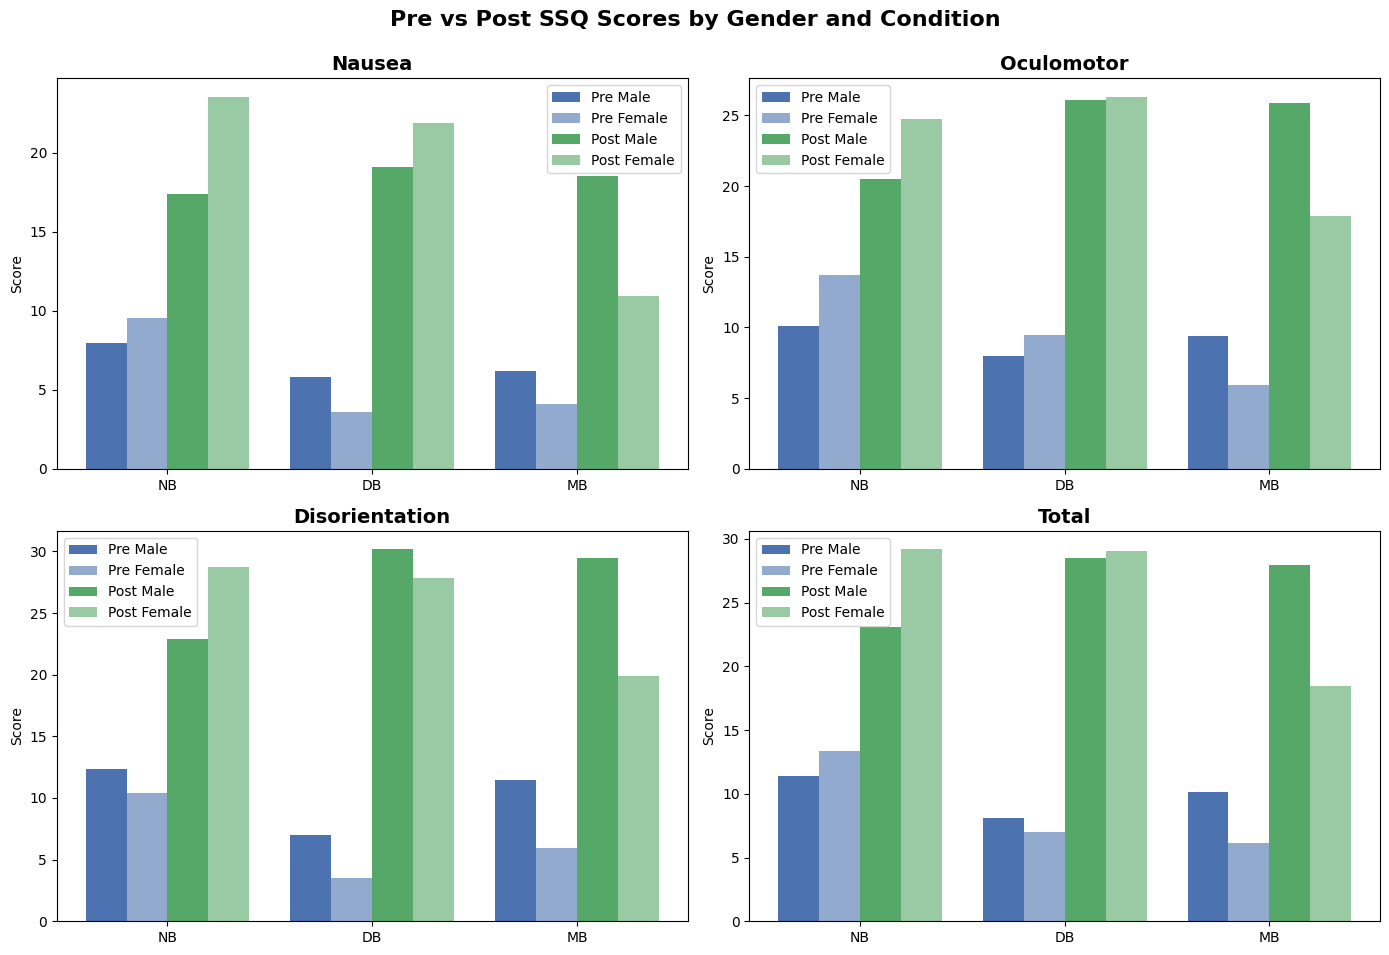

In [ ]:

# Male and female participant sets
male_indices = {1, 2, 5, 6, 7, 14, 15, 18, 20, 21, 22, 23, 27, 28, 30, 31, 32, 33}
female_indices = {3, 4, 8, 9, 10, 11, 12, 13, 16, 17, 19, 24, 25, 26, 29, 34}

# Filter pre and post data by gender
pre_male = pre_df[pre_df['Participant'].isin(male_indices)]
pre_female = pre_df[pre_df['Participant'].isin(female_indices)]
post_male = post_df[post_df['Participant'].isin(male_indices)]
post_female = post_df[post_df['Participant'].isin(female_indices)]

# Metrics and conditions
metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]
condition_order = ["NB", "DB", "MB"]

# Function to get mean scores by condition
def mean_by_condition(df):
    return df.groupby("Condition")[metrics].mean().loc[condition_order]

pre_male_means = mean_by_condition(pre_male)
pre_female_means = mean_by_condition(pre_female)
post_male_means = mean_by_condition(post_male)
post_female_means = mean_by_condition(post_female)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axes = axs.ravel()
bar_width = 0.2
x = np.arange(len(condition_order))

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.bar(x - 1.5*bar_width, pre_male_means[metric], width=bar_width, label='Pre Male', color='#4c72b0')
    ax.bar(x - 0.5*bar_width, pre_female_means[metric], width=bar_width, label='Pre Female', color='#4c72b0', alpha=0.6)
    ax.bar(x + 0.5*bar_width, post_male_means[metric], width=bar_width, label='Post Male', color='#55a868')
    ax.bar(x + 1.5*bar_width, post_female_means[metric], width=bar_width, label='Post Female', color='#55a868', alpha=0.6)

    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(condition_order)
    ax.set_ylabel("Score")
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Pre vs Post SSQ Scores by Gender and Condition", fontsize=16, fontweight='bold')
plt.show()


In [ ]:

# Male and female participant sets
male_indices = {1, 2, 5, 6, 7, 14, 15, 18, 20, 21, 22, 23, 27, 28, 30, 31, 32, 33}
female_indices = {3, 4, 8, 9, 10, 11, 12, 13, 16, 17, 19, 24, 25, 26, 29, 34}

# Metrics and condition order
metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]
condition_order = ["NB", "DB", "MB"]

# Function to compute mean and std for each metric by condition
def mean_std_by_gender(df, participant_set, gender_label):
    subset = df[df['Participant'].isin(participant_set)]
    stats = subset.groupby("Condition")[metrics].agg(['mean', 'std']).reindex(condition_order)
    stats.columns = [f"{metric}_{stat}" for metric, stat in stats.columns]
    stats['Gender'] = gender_label
    return stats

# Compute stats
pre_male_stats = mean_std_by_gender(pre_df, male_indices, "Male")
pre_female_stats = mean_std_by_gender(pre_df, female_indices, "Female")
post_male_stats = mean_std_by_gender(post_df, male_indices, "Male")
post_female_stats = mean_std_by_gender(post_df, female_indices, "Female")

# Combine
pre_stats = pd.concat([pre_male_stats, pre_female_stats])
post_stats = pd.concat([post_male_stats, post_female_stats])

post_stats


,Nausea_mean,Nausea_std,Oculomotor_mean,Oculomotor_std,Disorientation_mean,Disorientation_std,Total_mean,Total_std,Gender
Condition,,,,,,,,,
NB,17.396471,17.602300,20.510588,17.930487,22.927059,25.544801,23.100000,20.494863,Male
DB,19.080000,16.360965,26.108889,19.838285,30.160000,34.840917,28.465556,24.445477,Male
MB,18.518824,15.260492,25.861176,18.961144,29.477647,29.888461,27.940000,21.852518,Male
NB,23.532000,39.477402,24.761333,23.878576,28.768000,39.535414,29.172000,35.401821,Female
DB,21.885882,37.218948,26.307059,25.999186,27.840000,32.272192,29.040000,31.333785,Female
MB,10.902857,18.655947,17.867143,20.728247,19.885714,32.628983,18.432857,24.958152,Female


In [ ]:
import pandas as pd

# Male and female participant sets
male_indices = {1, 2, 5, 6, 7, 14, 15, 18, 20, 21, 22, 23, 27, 28, 30, 31, 32, 33}
female_indices = {3, 4, 8, 9, 10, 11, 12, 13, 16, 17, 19, 24, 25, 26, 29, 34}

metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]

def min_metric_summary(df, participant_set, gender_label):
    subset = df[df['Participant'].isin(participant_set)]
    results = {}
    total = subset["Participant"].nunique()

    for metric in metrics:
        min_rows = subset.loc[subset.groupby("Participant")[metric].idxmin()]
        counts = min_rows["Condition"].value_counts()
        results[metric] = {
            "Counts": counts.to_dict(),
            "Percent": (counts / total * 100).to_dict()
        }

    return pd.DataFrame({
        metric: {
            "Counts": results[metric]["Counts"],
            "Percent": results[metric]["Percent"]
        } for metric in metrics
    }), gender_label

# Compute for male and female
male_summary_df, male_label = min_metric_summary(post_df, male_indices, "Male")
female_summary_df, female_label = min_metric_summary(post_df, female_indices, "Female")

print(f"=== Minimum SSQ Metrics per Condition: {male_label} ===")
print(male_summary_df)

print(f"\n=== Minimum SSQ Metrics per Condition: {female_label} ===")
print(female_summary_df)


=== Minimum SSQ Metrics per Condition: Male ===
                                                    Nausea  \
Counts                       {'DB': 11, 'NB': 11, 'MB': 7}   
Percent  {'DB': 61.111111111111114, 'NB': 61.1111111111...   

                                                Oculomotor  \
Counts                       {'DB': 11, 'NB': 10, 'MB': 9}   
Percent  {'DB': 61.111111111111114, 'NB': 55.5555555555...   

                                            Disorientation  \
Counts                       {'NB': 12, 'DB': 10, 'MB': 6}   
Percent  {'NB': 66.66666666666666, 'DB': 55.55555555555...   

                                                     Total  
Counts                       {'DB': 11, 'NB': 11, 'MB': 6}  
Percent  {'DB': 61.111111111111114, 'NB': 61.1111111111...  

=== Minimum SSQ Metrics per Condition: Female ===
                                        Nausea  \
Counts            {'DB': 12, 'NB': 8, 'MB': 5}   
Percent  {'DB': 75.0, 'NB': 50.0, 'MB': 31.25}   

      

In [ ]:
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon

metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]

# Separate male and female participants
male_df = post_df[post_df['Participant'].isin(male_indices)]
female_df = post_df[post_df['Participant'].isin(female_indices)]

def friedman_and_posthoc(df, group_name):
    print(f"\n=== {group_name} ===")

    # Aggregate duplicates: take mean per participant per condition
    df_agg = df.groupby(['Participant', 'Condition'])[metrics].mean().reset_index()

    for metric in metrics:
        # Keep only participants with all three conditions
        pivot = df_agg.pivot(index='Participant', columns='Condition', values=metric)
        pivot = pivot[['NB', 'DB', 'MB']]  # ensure correct order
        pivot = pivot.dropna()  # remove participants with missing data

        if pivot.shape[0] == 0:
            print(f"{metric}: No participants with complete data.")
            continue

        # Friedman test
        stat, p = friedmanchisquare(pivot['NB'], pivot['DB'], pivot['MB'])
        print(f"{metric} - Friedman chi2={stat:.3f}, p={p:.4f}")

        # Pairwise Wilcoxon tests
        wilcox_pairs = [('NB', 'DB'), ('NB', 'MB'), ('DB', 'MB')]
        for a, b in wilcox_pairs:
            w_stat, w_p = wilcoxon(pivot[a], pivot[b])
            print(f"  Wilcoxon {a} vs {b}: W={w_stat:.3f}, p={w_p:.4f}")

# Run for males
friedman_and_posthoc(male_df, "Male Participants")

# Run for females
friedman_and_posthoc(female_df, "Female Participants")



=== Male Participants ===
Nausea - Friedman chi2=1.674, p=0.4329
  Wilcoxon NB vs DB: W=27.000, p=0.9592
  Wilcoxon NB vs MB: W=37.000, p=0.8746
  Wilcoxon DB vs MB: W=13.000, p=0.4778
Oculomotor - Friedman chi2=0.776, p=0.6786
  Wilcoxon NB vs DB: W=29.500, p=0.2617
  Wilcoxon NB vs MB: W=16.500, p=0.0771
  Wilcoxon DB vs MB: W=25.000, p=0.7986
Disorientation - Friedman chi2=3.389, p=0.1837
  Wilcoxon NB vs DB: W=15.500, p=0.7256
  Wilcoxon NB vs MB: W=13.000, p=0.2591
  Wilcoxon DB vs MB: W=14.500, p=0.6219
Total - Friedman chi2=1.385, p=0.5004
  Wilcoxon NB vs DB: W=41.500, p=0.4897
  Wilcoxon NB vs MB: W=35.000, p=0.2716
  Wilcoxon DB vs MB: W=21.000, p=0.5076

=== Female Participants ===
Nausea - Friedman chi2=0.087, p=0.9575
  Wilcoxon NB vs DB: W=9.500, p=0.8750
  Wilcoxon NB vs MB: W=5.000, p=0.6875
  Wilcoxon DB vs MB: W=6.500, p=0.8750
Oculomotor - Friedman chi2=1.187, p=0.5523
  Wilcoxon NB vs DB: W=10.000, p=0.5625
  Wilcoxon NB vs MB: W=8.500, p=0.4062
  Wilcoxon DB vs MB

In [ ]:
ages = [
    26, 28, 23, 27, 18, 24, 25, 21, 21, 22, 24, 26, 31, 29,
    28, 20, 31, 29, 25, 41, 23, 24, 27, 21, 59, 33, 26, 27, 35, 24,
    30, 22, 23, 25
]
import pandas as pd

# Map participant ID to age
participant_ids = sorted(df_all["Participant"].unique())
age_map = dict(zip(participant_ids, ages))

# Add Age column to post_min_df
post_min_df["Age"] = post_min_df["Participant"].map(age_map)

# Now define age groups
age_bins = [0, 20, 25, 30, 40, 50, 60, 100]
age_labels = ['<20', '21–25','26-30', '31–40', '41–50', '51–60', '60+']
post_min_df["Age_Group"] = pd.cut(post_min_df["Age"], bins=age_bins, labels=age_labels)

# Example: count preferred condition for Nausea by age group
age_pref_counts = post_min_df.groupby(["Age_Group", "Nausea_min_condition"]).size().unstack(fill_value=0)
print(age_pref_counts)


Nausea_min_condition  DB  MB  NB
Age_Group                       
<20                    2   0   0
21–25                  5   4   6
26-30                  7   1   3
31–40                  1   2   1
41–50                  0   0   1
51–60                  1   0   0
60+                    0   0   0


/tmp/ipython-input-1915278391.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_pref_counts = post_min_df.groupby(["Age_Group", "Nausea_min_condition"]).size().unstack(fill_value=0)


In [ ]:
participants = sorted(df_all["Participant"].unique())
age_map = dict(zip(participants, ages))
df_all["Age"] = df_all["Participant"].map(age_map)

# ---------- Assign age groups ----------
age_bins = [0, 20, 25, 30, 40, 50, 60, 100]
age_labels = ['<20', '21–25','26-30', '31–40', '41–50', '51–60', '60+']
df_all["Age_Group"] = pd.cut(df_all["Age"], bins=age_bins, labels=age_labels)

# ---------- Metrics and conditions ----------
metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]
conditions = ["NB", "DB", "MB"]

# ---------- Statistical significance testing ----------
for time_point in ["Pre", "Post"]:
    print(f"\n=== {time_point} Study ===")
    df_time = df_all[df_all["Time"] == time_point]

    for age_group in age_labels:
        df_age = df_time[df_time["Age_Group"] == age_group]
        if df_age.empty:
            continue
        print(f"\n--- Age Group: {age_group} ---")

        for metric in metrics:
            # Pivot so each participant is a row, conditions are columns
            pivot = df_age.pivot(index="Participant", columns="Condition", values=metric)
            # Keep only participants with all three conditions
            pivot = pivot.dropna(subset=conditions)
            if pivot.shape[0] < 2:
                print(f"{metric}: Not enough participants to test")
                continue

            # Friedman test
            try:
                stat, p = friedmanchisquare(*(pivot[c].values for c in conditions))
                print(f"{metric} - Friedman chi2={stat:.3f}, p={p:.4f}")
            except Exception as e:
                print(f"{metric} - Error in Friedman test: {e}")
                continue

            # Pairwise Wilcoxon post-hoc (only if Friedman significant)
            if p < 0.05:
                for i, cond1 in enumerate(conditions):
                    for j, cond2 in enumerate(conditions):
                        if i >= j:
                            continue
                        w_stat, w_p = wilcoxon(pivot[cond1], pivot[cond2])
                        print(f"  Wilcoxon {cond1} vs {cond2}: W={w_stat:.3f}, p={w_p:.4f}")


=== Pre Study ===

--- Age Group: <20 ---
Nausea: Not enough participants to test
Oculomotor: Not enough participants to test
Disorientation: Not enough participants to test
Total: Not enough participants to test

--- Age Group: 21–25 ---
Nausea - Friedman chi2=0.074, p=0.9636
Oculomotor - Friedman chi2=1.400, p=0.4966
Disorientation - Friedman chi2=1.407, p=0.4947
Total - Friedman chi2=0.914, p=0.6331

--- Age Group: 26-30 ---
Nausea - Friedman chi2=2.471, p=0.2907
Oculomotor - Friedman chi2=2.111, p=0.3480
Disorientation - Friedman chi2=2.286, p=0.3189
Total - Friedman chi2=2.842, p=0.2415

--- Age Group: 31–40 ---
Nausea - Friedman chi2=nan, p=nan
Oculomotor - Friedman chi2=4.000, p=0.1353
Disorientation - Friedman chi2=2.000, p=0.3679
Total - Friedman chi2=4.000, p=0.1353

--- Age Group: 41–50 ---
Nausea: Not enough participants to test
Oculomotor: Not enough participants to test
Disorientation: Not enough participants to test
Total: Not enough participants to test

--- Age Group:

/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:8780: RuntimeWarning: invalid value encountered in scalar divide
  statistic = (12.0 / (k*n*(k+1)) * ssbn - 3*n*(k+1)) / c


ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon

# ---------- Load data ----------
pre_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores.csv")
post_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores.csv")
pre_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores_ksu.csv")
post_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores_ksu.csv")

pre_df = pd.concat([pre_df1, pre_df2], axis=0)
post_df = pd.concat([post_df1, post_df2], axis=0)

pre_df["Time"] = "Pre"
post_df["Time"] = "Post"

df_all = pd.concat([pre_df, post_df], axis=0)

# ---------- Participant ages ----------
ages = [
    26, 28, 23, 27, 18, 24, 25, 21, 21, 22, 24, 26, 31, 29,
    28, 20, 31, 29, 25, 41, 23, 24, 27, 21, 59, 33, 26, 27, 35, 24,
    30, 22, 23, 25
]

# Assign ages to participants
participants_sorted = sorted(df_all["Participant"].unique())
age_dict = dict(zip(participants_sorted, ages[:len(participants_sorted)]))
df_all["Age"] = df_all["Participant"].map(age_dict)

# Create age groups
age_bins = [0, 20, 25, 30, 40, 50, 60, 100]
age_labels = ['<20', '21–25','26-30', '31–40', '41–50', '51–60', '60+']
df_all["Age_Group"] = pd.cut(df_all["Age"], bins=age_bins, labels=age_labels)

def friedman_and_posthoc(df, group_name):
    metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]
    print(f"\n=== {group_name} ===")

    for metric in metrics:
        # Aggregate duplicate participant-condition entries
        df_agg = df.groupby(["Participant", "Condition"])[metric].mean().reset_index()

        # Pivot to shape: Participant x Condition
        pivot = df_agg.pivot(index="Participant", columns="Condition", values=metric)

        # Drop participants with missing conditions
        pivot = pivot.dropna()

        if pivot.shape[0] < 2 or pivot.shape[1] < 2:
            print(f"{metric}: Not enough data to perform test (participants={pivot.shape[0]}, conditions={pivot.shape[1]})")
            continue

        # Friedman test
        stat, p = friedmanchisquare(*[pivot[col] for col in pivot.columns])
        print(f"{metric} - Friedman chi2={stat:.3f}, p={p:.4f}")

        # Wilcoxon post-hoc pairwise comparisons
        conditions = pivot.columns.tolist()
        for i in range(len(conditions)):
            for j in range(i+1, len(conditions)):
                cond1, cond2 = conditions[i], conditions[j]

                # Only run Wilcoxon if at least 2 paired observations
                paired_data = pivot[[cond1, cond2]].dropna()
                if paired_data.shape[0] < 2:
                    print(f"  Wilcoxon {cond1} vs {cond2}: Not enough paired data")
                    continue

                w_stat, w_p = wilcoxon(paired_data[cond1], paired_data[cond2])
                print(f"  Wilcoxon {cond1} vs {cond2}: W={w_stat:.3f}, p={w_p:.4f}")

# ---------- Run tests per age group ----------
for time_point in ["Pre", "Post"]:
    print(f"\n----- {time_point} Study -----")
    df_time = df_all[df_all["Time"] == time_point]

    for age_group in age_labels:
        df_age = df_time[df_time["Age_Group"] == age_group]
        if df_age.empty:
            continue
        friedman_and_posthoc(df_age, f"Age Group {age_group}")



----- Pre Study -----

=== Age Group <20 ===
Nausea: Not enough data to perform test (participants=1, conditions=3)
Oculomotor: Not enough data to perform test (participants=1, conditions=3)
Disorientation: Not enough data to perform test (participants=1, conditions=3)
Total: Not enough data to perform test (participants=1, conditions=3)

=== Age Group 21–25 ===
Nausea - Friedman chi2=0.074, p=0.9636
  Wilcoxon DB vs MB: W=9.000, p=1.0000
  Wilcoxon DB vs NB: W=6.500, p=1.0000
  Wilcoxon MB vs NB: W=18.000, p=1.0000
Oculomotor - Friedman chi2=1.400, p=0.4966
  Wilcoxon DB vs MB: W=10.500, p=0.6562
  Wilcoxon DB vs NB: W=6.000, p=0.2031
  Wilcoxon MB vs NB: W=15.500, p=0.7734
Disorientation - Friedman chi2=1.407, p=0.4947
  Wilcoxon DB vs MB: W=10.000, p=0.3594
  Wilcoxon DB vs NB: W=10.000, p=1.0000
  Wilcoxon MB vs NB: W=4.500, p=0.5625
Total - Friedman chi2=0.914, p=0.6331
  Wilcoxon DB vs MB: W=21.500, p=0.9336
  Wilcoxon DB vs NB: W=10.000, p=0.5781
  Wilcoxon MB vs NB: W=17.000, 

/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:8780: RuntimeWarning: invalid value encountered in scalar divide
  statistic = (12.0 / (k*n*(k+1)) * ssbn - 3*n*(k+1)) / c
/usr/local/lib/python3.11/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.11/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.11/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.11/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.11/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.11/dist-packages/sc

  Wilcoxon DB vs MB: W=8.000, p=0.6250
  Wilcoxon DB vs NB: W=6.000, p=0.8125
  Wilcoxon MB vs NB: W=4.000, p=0.4375
Oculomotor - Friedman chi2=1.200, p=0.5488
  Wilcoxon DB vs MB: W=14.500, p=0.6797
  Wilcoxon DB vs NB: W=6.000, p=0.2344
  Wilcoxon MB vs NB: W=14.500, p=0.3828
Disorientation - Friedman chi2=1.931, p=0.3808
  Wilcoxon DB vs MB: W=16.000, p=0.8281
  Wilcoxon DB vs NB: W=8.500, p=0.7188
  Wilcoxon MB vs NB: W=5.000, p=0.2812
Total - Friedman chi2=0.585, p=0.7463
  Wilcoxon DB vs MB: W=26.000, p=0.9004
  Wilcoxon DB vs NB: W=17.500, p=0.3340
  Wilcoxon MB vs NB: W=17.000, p=0.3105

=== Age Group 26-30 ===
Nausea - Friedman chi2=0.250, p=0.8825
  Wilcoxon DB vs MB: W=6.500, p=0.8750
  Wilcoxon DB vs NB: W=19.000, p=0.7148
  Wilcoxon MB vs NB: W=16.000, p=0.4688
Oculomotor - Friedman chi2=0.250, p=0.8825
  Wilcoxon DB vs MB: W=7.000, p=0.2969
  Wilcoxon DB vs NB: W=16.000, p=0.4922
  Wilcoxon MB vs NB: W=11.000, p=0.6562
Disorientation - Friedman chi2=0.240, p=0.8869
  Wilc

difference between the physiological signal in different condition

In [ ]:
!unzip '/content/drive/MyDrive/Blur study data.zip'
!unzip '/content/drive/MyDrive/Blur study data2.zip'

Archive:  /content/drive/MyDrive/Blur study data.zip
   creating: Blur study data/
  inflating: Blur study data/all_participants_combined.csv  
   creating: Blur study data/Participant_1/
  inflating: Blur study data/Participant_1/baseline_ECG_data_participant1.csv  
  inflating: Blur study data/Participant_1/baseline_GSR_data_participant1.csv  
  inflating: Blur study data/Participant_1/feedback_part.csv  
  inflating: Blur study data/Participant_1/Filtered_ECG_512Hz.csv  
  inflating: Blur study data/Participant_1/Filtered_GSR_PPG.csv  
  inflating: Blur study data/Participant_1/labeled_ECG_data_participant1.csv  
  inflating: Blur study data/Participant_1/labeled_eye_data_participant1.csv  
  inflating: Blur study data/Participant_1/labeled_GSR_data_participant1.csv  
  inflating: Blur study data/Participant_1/labeled_head_data_participant1.csv  
  inflating: Blur study data/Participant_1/merged_labeled_data_participant1.csv  
  inflating: Blur study data/Participant_1/merged_resamp

In [ ]:
from scipy.signal import resample
import pandas as pd
import os
from datetime import timedelta

def resample_ecg_data(df, original_rate, target_rate=250):
    if 'Timestamp' not in df.columns:
        raise ValueError("Timestamp column is required to regenerate timestamps.")

    start_time = pd.to_datetime(df['Timestamp'].iloc[0])

    # Mode-preserved columns
    preserve_cols = {}
    for col in ['FMS', 'Condition']:
        if col in df.columns:
            preserve_cols[col] = df[col].mode().iloc[0]

    # Select numeric signal columns only (excluding mode-preserved columns if numeric)
    signal_df = df.select_dtypes(include='number').copy()
    for col in preserve_cols:
        if col in signal_df.columns:
            signal_df.drop(columns=col, inplace=True)

    # Resample signal
    num_original_samples = len(signal_df)
    num_target_samples = int(num_original_samples * target_rate / original_rate)
    resampled_array = resample(signal_df.values, num_target_samples, axis=0)
    resampled_df = pd.DataFrame(resampled_array, columns=signal_df.columns)

    # Add preserved columns with constant mode value
    for col, mode_val in preserve_cols.items():
        resampled_df[col] = mode_val

    # Reconstruct timestamps
    interval = 1 / target_rate
    resampled_timestamps = [start_time + timedelta(seconds=i * interval) for i in range(num_target_samples)]
    resampled_df['Timestamp'] = resampled_timestamps

    return resampled_df



def load_participant_data(base_path, participant_ids, subfolder_prefix, filename_prefix, resample_ecg=False, original_rate=None):
    all_data = []

    for pid in participant_ids:
        file_path = os.path.join(base_path, f"{subfolder_prefix}{pid}", f"{filename_prefix}{pid}.csv")

        try:
            df = pd.read_csv(file_path)

            print(f"[Participant {pid}] Missing values:\n", df.isna().sum())
            df.dropna(inplace=True)

            if resample_ecg:
                if original_rate is None:
                    raise ValueError("Original sampling rate must be provided for ECG resampling.")
                df = resample_ecg_data(df, original_rate)
            df['participant'] = pid
            all_data.append(df)

        except FileNotFoundError:
            print(f"File not found for participant {pid}: {file_path}")
        except pd.errors.EmptyDataError:
            print(f"Empty or invalid file for participant {pid}: {file_path}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

base_path = r'/content/Blur study data'

participant_ids_train = range(1, 16)
# participant_ids_test = range(13, 15)

# ECG
original_ecg_rate = 500
train_ecg_data1 = load_participant_data(
    base_path,
    participant_ids_train,
    "Participant_",
    "labeled_ECG_data_participant",
    resample_ecg=True,
    original_rate=original_ecg_rate
)
# Eye Tracking
train_eye_data1 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_eye_data_participant")
# test_eye_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_eye_participant")

# Head Tracking
train_head_data1 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_head_data_participant")
# test_head_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_head_data_participant")

# GSR (Galvanic Skin Response)
train_gsr_data1 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_GSR_data_participant")
# test_gsr_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_GSR_data_participant")



/tmp/ipython-input-126074403.py:50: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 1] Missing values:
 Timestamp                           0
ECG_test1_ECGtoHR_LA_RA_CAL         0
Lead I (LA-RA)                      0
Lead II (LL-LA)                     0
Lead III (LL-RA)                    0
Vx-RL                               0
FMS                            612197
Condition                      612197
dtype: int64


/tmp/ipython-input-126074403.py:50: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 2] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 639427
Condition           623555
dtype: int64


/tmp/ipython-input-126074403.py:50: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


...

[Participant 11] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 531434
Condition           531434
dtype: int64


/tmp/ipython-input-126074403.py:50: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 12] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 333389
Condition           333389
dtype: int64


/tmp/ipython-input-126074403.py:50: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 13] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 389276
Condition           389276
dtype: int64
[Participant 14] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 263714
Condition           263714
dtype: int64
[Participant 15] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 245756
Condition           245756
dtype: int64
[Participant 1] Missing values:
 timestamp                               0
LeftEye_Openness_Openness               0
RightEye_Openness_Openness              0
LeftEye_PupilDilation_PupilDilation     0
RightEye_PupilDilation_PupilDilation    0
LeftEye_PupilPosition_X                 0
LeftEye

In [ ]:
def load_participant_data(
    base_path, participant_ids, subfolder_prefix, filename_prefix,
    resample_ecg=False, original_rate=None, auto_detect_sampling=False
):
    all_data = []

    for pid in participant_ids:
        file_path = os.path.join(base_path, f"{subfolder_prefix}{pid}", f"{filename_prefix}{pid}.csv")

        try:
            df = pd.read_csv(file_path)

            print(f"[Participant {pid}] Missing values:\n", df.isna().sum())
            df.dropna(inplace=True)
            if df.empty:
                print(f"Empty DataFrame for participant {pid}: {file_path}")
                continue

            if resample_ecg:
                # Only resample if auto_detect_sampling is enabled and actual rate is different
                if auto_detect_sampling:
                    timestamps = pd.to_datetime(df["Timestamp"])
                    # Compute actual rate (based on median interval)
                    actual_interval = (timestamps.diff().dt.total_seconds().median())
                    actual_rate = round(1 / actual_interval) if actual_interval else None
                    print(f"[Participant {pid}] Detected ECG rate: {actual_rate} Hz")

                    if actual_rate and actual_rate != 250:
                        df = resample_ecg_data(df, actual_rate)
                else:
                    if original_rate is None:
                        raise ValueError("Original sampling rate must be provided for ECG resampling.")
                    df = resample_ecg_data(df, original_rate)

            df['participant'] = pid
            all_data.append(df)

        except FileNotFoundError:
            print(f"File not found for participant {pid}: {file_path}")
        except pd.errors.EmptyDataError:
            print(f"Empty or invalid file for participant {pid}: {file_path}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()
def resample_ecg_data(df, original_rate, target_rate=250):
    if 'Timestamp' not in df.columns:
        raise ValueError("Timestamp column is required to regenerate timestamps.")

    start_time = pd.to_datetime(df['Timestamp'].iloc[0])

    # Mode-preserved columns
    preserve_cols = {}
    for col in ['FMS', 'Condition']:
        if col in df.columns:
            preserve_cols[col] = df[col].mode().iloc[0]

    # Select numeric signal columns only (excluding mode-preserved columns if numeric)
    signal_df = df.select_dtypes(include='number').copy()
    for col in preserve_cols:
        if col in signal_df.columns:
            signal_df.drop(columns=col, inplace=True)

    # Resample signal
    num_original_samples = len(signal_df)
    num_target_samples = int(num_original_samples * target_rate / original_rate)
    resampled_array = resample(signal_df.values, num_target_samples, axis=0)
    resampled_df = pd.DataFrame(resampled_array, columns=signal_df.columns)

    # Add preserved columns with constant mode value
    for col, mode_val in preserve_cols.items():
        resampled_df[col] = mode_val

    # Reconstruct timestamps
    interval = 1 / target_rate
    resampled_timestamps = [start_time + timedelta(seconds=i * interval) for i in range(num_target_samples)]
    resampled_df['Timestamp'] = resampled_timestamps

    return resampled_df
participant_ids_dataset3 = range(1, 16)
base_path='/content/drive/MyDrive/CyberSense/User Study/User Study Data/Processed data'
# ECG: Let the loader detect which files to resample
train_ecg_data3 = load_participant_data(
    base_path,
    participant_ids_dataset3,
    "Participant_",
    "labeled_ECG_data_participant",
    resample_ecg=True,
    auto_detect_sampling=True  # Automatically detects sampling rate
)

# Other signals (already 250 Hz)
#train_eye_data3 = load_participant_data(base_path, participant_ids_dataset3, "Participant_", "labeled_eye_data_participant")
train_head_data3 = load_participant_data(base_path, participant_ids_dataset3, "Participant_", "labeled_head_data_participant")
train_gsr_data3 = load_participant_data(base_path, participant_ids_dataset3, "Participant_", "labeled_GSR_data_participant")

train_ecg_data3

[Participant 1] Missing values:
 Timestamp               0
Lead I (LA-RA)          0
Lead II (LL-LA)         0
Lead III (LL-RA)        0
Vx-RL                   0
FMS                 33772
Condition            2740
dtype: int64
[Participant 1] Detected ECG rate: 500 Hz


/tmp/ipython-input-1971352082.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 2] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 309530
Condition           309530
dtype: int64
[Participant 2] Detected ECG rate: 250 Hz


/tmp/ipython-input-1971352082.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 3] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 306289
Condition           306289
dtype: int64
[Participant 3] Detected ECG rate: 250 Hz
[Participant 4] Missing values:
 Timestamp              0
Lead I (LA-RA)         0
Lead II (LL-LA)        0
Lead III (LL-RA)       0
Vx-RL                  0
FMS                 8411
Condition           8411
dtype: int64
[Participant 4] Detected ECG rate: 250 Hz
[Participant 5] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 213455
Condition           213455
dtype: int64
[Participant 5] Detected ECG rate: 250 Hz
[Participant 6] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS            

/tmp/ipython-input-1971352082.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 9] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 305490
Condition           305490
dtype: int64
[Participant 9] Detected ECG rate: 250 Hz
[Participant 10] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 417179
Condition           417179
dtype: int64
[Participant 10] Detected ECG rate: 250 Hz
[Participant 11] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 231889
Condition           231889
dtype: int64
[Participant 11] Detected ECG rate: 250 Hz
[Participant 12] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                  

/tmp/ipython-input-1971352082.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 15] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 244027
Condition           236094
dtype: int64
[Participant 15] Detected ECG rate: 250 Hz
[Participant 1] Missing values:
 Time              0
#Frame            0
HeadQRotationX    0
HeadQRotationY    0
HeadQRotationZ    0
HeadQRotationW    0
HeadEulX          0
HeadEulY          0
HeadEulZ          0
FMS               0
Condition         0
dtype: int64
[Participant 2] Missing values:
 Time              0
#Frame            0
HeadQRotationX    0
HeadQRotationY    0
HeadQRotationZ    0
HeadQRotationW    0
HeadEulX          0
HeadEulY          0
HeadEulZ          0
FMS               0
Condition         0
dtype: int64
[Participant 3] Missing values:
 Time              0
#Frame            0
HeadQRotationX    0
HeadQRotationY    0
HeadQRotationZ    0
HeadQRotationW    0
HeadEulX          0
HeadEulY        

,Lead I (LA-RA),Lead II (LL-LA),Lead III (LL-RA),Vx-RL,FMS,Condition,Timestamp,participant
0,0.083909,-0.075311,0.008598,-0.055048,8.0,NB,2025-05-06 16:32:46.810000,1
1,0.146116,-0.067326,0.078791,-0.087042,8.0,NB,2025-05-06 16:32:46.814000,1
2,0.136238,-0.062681,0.073557,-0.065467,8.0,NB,2025-05-06 16:32:46.818000,1
3,0.140020,-0.052573,0.087448,-0.070618,8.0,NB,2025-05-06 16:32:46.822000,1
4,0.084118,-0.045535,0.038583,-0.060620,8.0,NB,2025-05-06 16:32:46.826000,1
...,...,...,...,...,...,...,...,...
1457484,-0.072107,0.127933,0.055826,-0.174796,5.0,NB,2025-06-25 18:37:49.091,15
1457485,-0.079731,0.134851,0.055121,-0.168986,5.0,NB,2025-06-25 18:37:49.095,15
1457486,-0.091567,0.145087,0.053520,-0.160686,5.0,NB,2025-06-25 18:37:49.099,15
1457487,-0.098998,0.156676,0.057677,-0.150513,5.0,NB,2025-06-25 18:37:49.103,15


In [ ]:
import numpy as np
id_offset = train_ecg_data1['participant'].max()

# train_eye_data3['participant'] += id_offset
train_head_data3['participant'] += id_offset
train_gsr_data3['participant'] += id_offset
train_ecg_data3['participant'] += id_offset
print(np.unique(train_ecg_data1['participant']),np.unique(train_ecg_data3['participant']))



[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] [16 17 18 19 20 21 24 25 26 27 28 29 30]


In [ ]:

all_data_gsr = pd.concat([train_gsr_data1, train_gsr_data3], ignore_index=True)
all_data_ecg = pd.concat([train_ecg_data1, train_ecg_data3], ignore_index=True)

all_data_gsr['FMS'] = (
    all_data_gsr['FMS']
    .astype(str)
    .str.replace('*', '', regex=False)  # remove asterisk
    .str.strip()
)
all_data_ecg['FMS']=(all_data_ecg['FMS']
    .astype(str)
    .str.replace('*', '', regex=False)  # remove asterisk
    .str.strip()
)
all_data_ecg['FMS']=pd.to_numeric(all_data_ecg['FMS'], errors='coerce')

all_data_gsr['FMS'] = pd.to_numeric(all_data_gsr['FMS'], errors='coerce')
all_data_gsr

,Timestamp,GSR_Filtered,PPG_Filtered,FMS,Condition,participant
0,2025-04-04 16:56:03.759,0.001744,123.558662,4.0,NB,1
1,2025-04-04 16:56:03.778,0.003374,191.259492,4.0,NB,1
2,2025-04-04 16:56:03.798,0.004946,241.255469,4.0,NB,1
3,2025-04-04 16:56:03.817,0.006283,261.810151,4.0,NB,1
4,2025-04-04 16:56:03.837,0.007244,245.547978,4.0,NB,1
...,...,...,...,...,...,...
1769336,2025-06-25 18:37:49.074,-0.000104,-1.919787,5.0,NB,30
1769337,2025-06-25 18:37:49.081,-0.000182,-3.024155,5.0,NB,30
1769338,2025-06-25 18:37:49.089,-0.000261,-4.156642,5.0,NB,30
1769339,2025-06-25 18:37:49.097,-0.000341,-5.299112,5.0,NB,30


In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 4.4 MB/s eta 0:00:00


   participant Condition  GSR_Filtered  PPG_Filtered
0            1        DB      0.000053     -0.033488
1            1        MB      0.000001      0.008778
2            1        NB      0.000008      0.026349
3            2        DB     -0.000029     -0.073896
4            2        MB     -0.000004     -0.430210


/tmp/ipython-input-3515672423.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary, x='Condition', y='GSR_Filtered', palette="Set2")


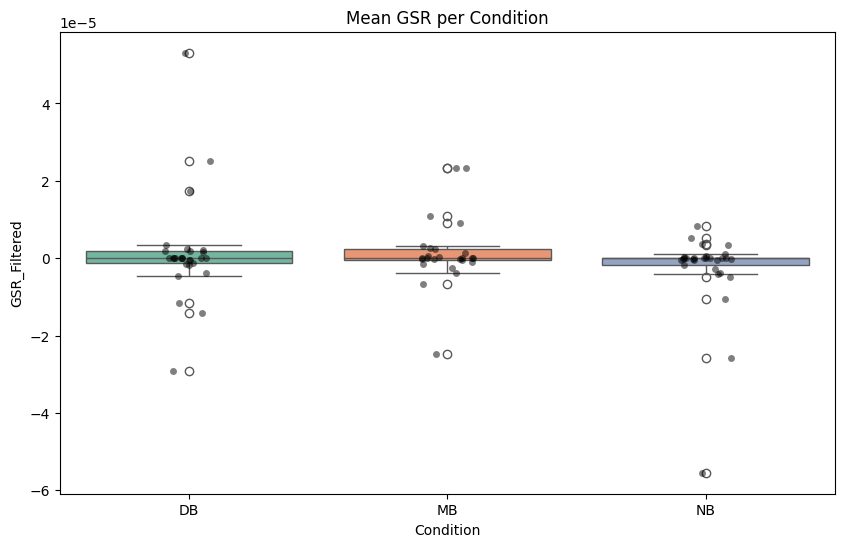

/tmp/ipython-input-3515672423.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary, x='Condition', y='PPG_Filtered', palette="Set3")


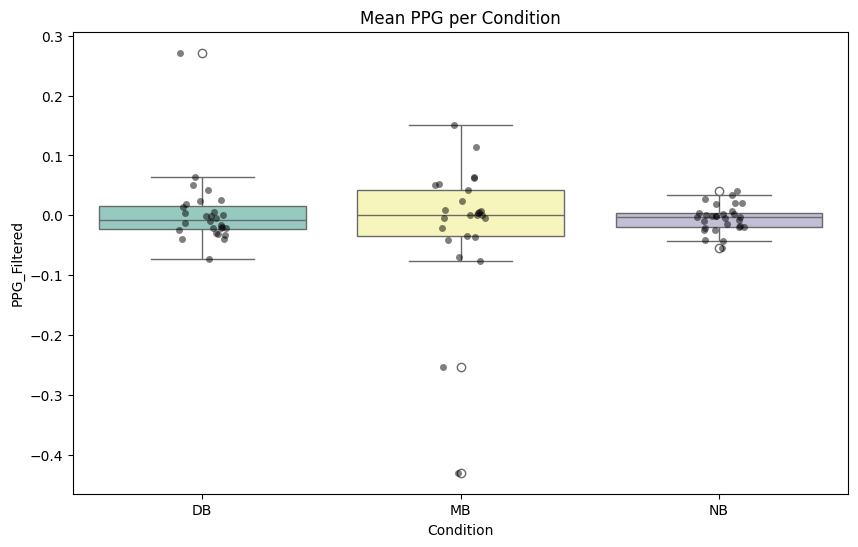

/usr/local/lib/python3.12/dist-packages/pingouin/distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
/usr/local/lib/python3.12/dist-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


Repeated-measures ANOVA - GSR:
      Source  ddof1  ddof2       F     p-unc       ng2       eps
0  Condition      2     48  1.4816  0.237481  0.037608  0.988536

Repeated-measures ANOVA - PPG:
      Source  ddof1  ddof2         F     p-unc  p-GG-corr       ng2       eps  \
0  Condition      2     48  0.471265  0.627069   0.587028  0.011826  0.807316   

   sphericity   W-spher   p-spher  
0       False  0.761328  0.043458  

Post-hoc tests GSR:
     Contrast   A   B  Paired  Parametric         T   dof alternative  \
0  Condition  DB  MB    True        True  0.099349  24.0   two-sided   
1  Condition  DB  NB    True        True  1.564105  24.0   two-sided   
2  Condition  MB  NB    True        True  1.369967  24.0   two-sided   

      p-unc    p-corr p-adjust   BF10    hedges  
0  0.921686  1.000000     bonf  0.212  0.026321  
1  0.130884  0.392653     bonf  0.615  0.376790  
2  0.183378  0.550135     bonf  0.484  0.436403  

Post-hoc tests PPG:
     Contrast   A   B  Paired  Parametri

/usr/local/lib/python3.12/dist-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pingouin as pg  # for ANOVA with repeated measures

# -----------------------------
# Step 1: Compute participant-level means
# -----------------------------
summary = all_data_gsr.groupby(['participant', 'Condition'])[['GSR_Filtered', 'PPG_Filtered']].mean().reset_index()

print(summary.head())

plt.figure(figsize=(10,6))
sns.boxplot(data=summary, x='Condition', y='GSR_Filtered', palette="Set2")
sns.stripplot(data=summary, x='Condition', y='GSR_Filtered', color='black', alpha=0.5)
plt.title("Mean GSR per Condition")
plt.show()


plt.figure(figsize=(10,6))
sns.boxplot(data=summary, x='Condition', y='PPG_Filtered', palette="Set3")
sns.stripplot(data=summary, x='Condition', y='PPG_Filtered', color='black', alpha=0.5)
plt.title("Mean PPG per Condition")
plt.show()

# -----------------------------
# -----------------------------
# Step 3: Statistical analysis
# -----------------------------

# Convert to long format for rmANOVA
gsr_long = summary[['participant', 'Condition', 'GSR_Filtered']]
ppg_long = summary[['participant', 'Condition', 'PPG_Filtered']]

# Run repeated-measures ANOVA
gsr_anova = pg.rm_anova(dv='GSR_Filtered', within='Condition', subject='participant', data=gsr_long)
ppg_anova = pg.rm_anova(dv='PPG_Filtered', within='Condition', subject='participant', data=ppg_long)

print("Repeated-measures ANOVA - GSR:")
print(gsr_anova)
print("\nRepeated-measures ANOVA - PPG:")
print(ppg_anova)

# -----------------------------
# Step 4: Post-hoc pairwise tests
# -----------------------------
gsr_posthoc = pg.pairwise_ttests(dv='GSR_Filtered', within='Condition', subject='participant', data=gsr_long, padjust='bonf')
ppg_posthoc = pg.pairwise_ttests(dv='PPG_Filtered', within='Condition', subject='participant', data=ppg_long, padjust='bonf')

print("\nPost-hoc tests GSR:\n", gsr_posthoc)
print("\nPost-hoc tests PPG:\n", ppg_posthoc)



   participant Condition  ECG_LeadII
0            1        MB    0.000008
1            2        NB    0.000155
2            3        DB   -0.000019
3            4        MB    0.000015
4            5        MB   -0.000010


/tmp/ipython-input-4188759694.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary, x='Condition', y='ECG_LeadII', palette="Set1")


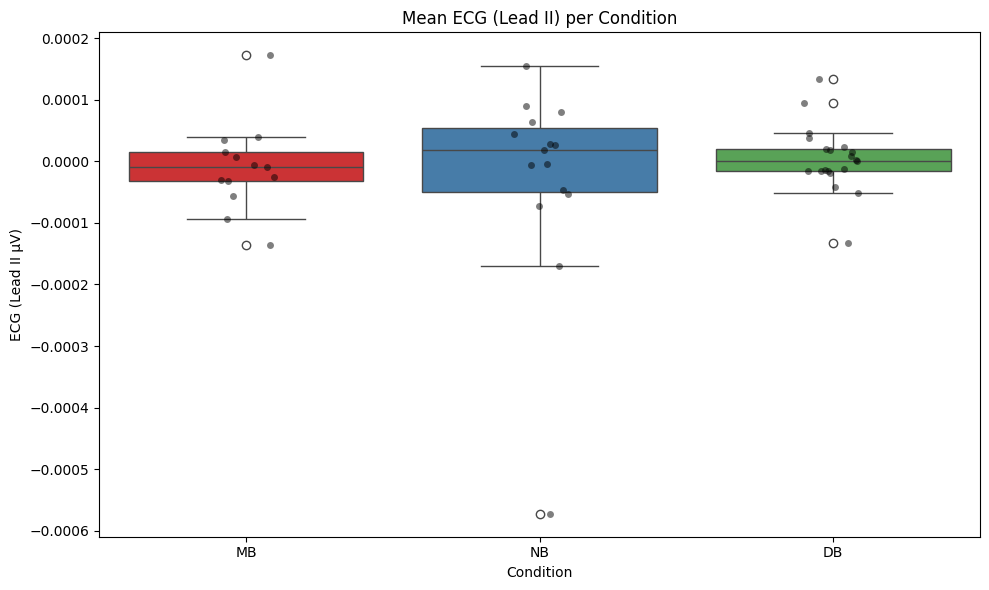


Repeated-measures ANOVA - ECG (Lead II):
      Source  ddof1  ddof2         F     p-unc       ng2       eps
0  Condition      2     16  0.294062  0.749172  0.025108  0.846815

Post-hoc tests ECG (Lead II):
     Contrast   A   B  Paired  Parametric         T  dof alternative     p-unc  \
0  Condition  DB  MB    True        True  0.415595  8.0   two-sided  0.688630   
1  Condition  DB  NB    True        True  0.658349  8.0   two-sided  0.528801   
2  Condition  MB  NB    True        True  0.430194  8.0   two-sided  0.678408   

   p-corr p-adjust   BF10    hedges  
0     1.0     bonf  0.346  0.245011  
1     1.0     bonf  0.385  0.309617  
2     1.0     bonf  0.348  0.174652  


/usr/local/lib/python3.12/dist-packages/pingouin/distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
/usr/local/lib/python3.12/dist-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg  # for ANOVA with repeated measures

# -----------------------------
# Step 1: Compute participant-level means
# -----------------------------
summary = all_data_ecg.groupby(['participant', 'Condition'])[['Lead II (LL-LA)']].mean().reset_index()
summary = summary.rename(columns={'Lead II (LL-LA)': 'ECG_LeadII'})

print(summary.head())

# -----------------------------
# Step 2: Visualization
# -----------------------------
plt.figure(figsize=(10,6))
sns.boxplot(data=summary, x='Condition', y='ECG_LeadII', palette="Set1")
sns.stripplot(data=summary, x='Condition', y='ECG_LeadII', color='black', alpha=0.5)
plt.title("Mean ECG (Lead II) per Condition")
plt.ylabel("ECG (Lead II µV)")  # Modify the unit as appropriate
plt.xlabel("Condition")
plt.tight_layout()
plt.show()

# -----------------------------
# Step 3: Statistical analysis (repeated-measures ANOVA)
# -----------------------------
ecg_long = summary[['participant', 'Condition', 'ECG_LeadII']]

ecg_anova = pg.rm_anova(dv='ECG_LeadII', within='Condition', subject='participant', data=ecg_long)

print("\nRepeated-measures ANOVA - ECG (Lead II):")
print(ecg_anova)

# -----------------------------
# Step 4: Post-hoc pairwise comparisons
# -----------------------------
ecg_posthoc = pg.pairwise_ttests(
    dv='ECG_LeadII',
    within='Condition',
    subject='participant',
    data=ecg_long,
    padjust='bonf'
)

print("\nPost-hoc tests ECG (Lead II):\n", ecg_posthoc)


   participant Condition  ECG_Baseline   ECG_End  ECG_MeanChange  \
0            1        MB      0.001581  0.012306        0.010725   
1            2        NB      0.112823  0.011820       -0.101004   
2            3        DB      0.019640 -0.011592       -0.031233   
3            4        MB     -0.069379  0.068658        0.138037   
4            5        MB      0.019372 -0.037285       -0.056657   

   ECG_PeakChange  ECG_MinChange   ECG_Range     ECG_Slope       ECG_AUC  \
0        1.047717      -0.728613    1.776330 -1.177315e-09   -146.180699   
1        1.005947      -1.075327    2.081274 -2.062869e-09 -13037.768924   
2        1.210314      -0.735970    1.946283  4.963243e-10  -2737.532619   
3        2.420858      -0.407553    2.828410  1.514990e-09   9646.813942   
4      133.569299     -19.931663  153.500962  2.614615e-10  -2694.354961   

    ECG_Std  ECG_NormMeanChange  ECG_NormPeakChange  
0  0.092865            6.785867          662.877157  
1  0.180052           -0.8

/tmp/ipython-input-2197593764.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ecg_df, x='Condition', y=metric, palette="Set3")


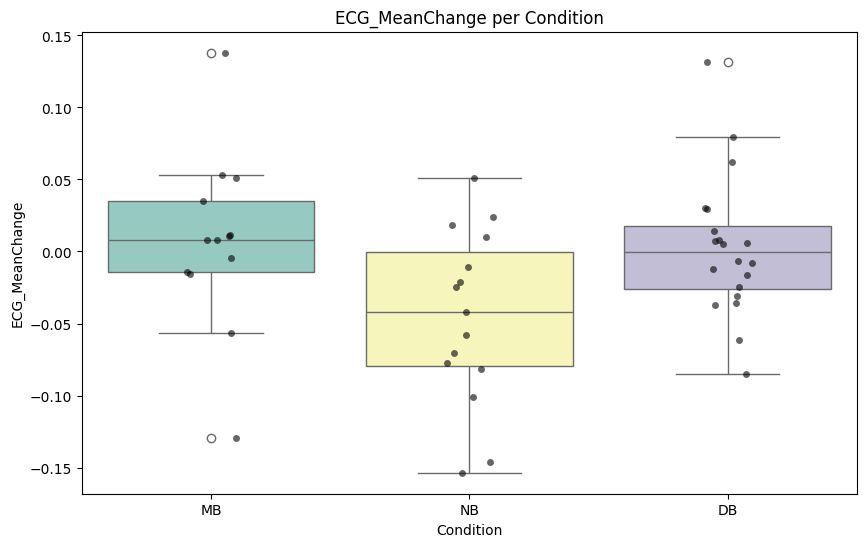

/tmp/ipython-input-2197593764.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ecg_df, x='Condition', y=metric, palette="Set3")


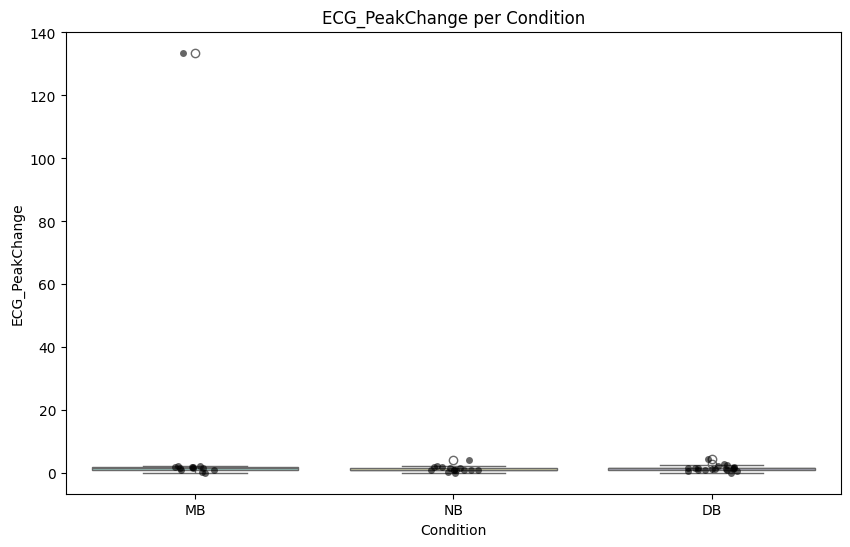

/tmp/ipython-input-2197593764.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ecg_df, x='Condition', y=metric, palette="Set3")


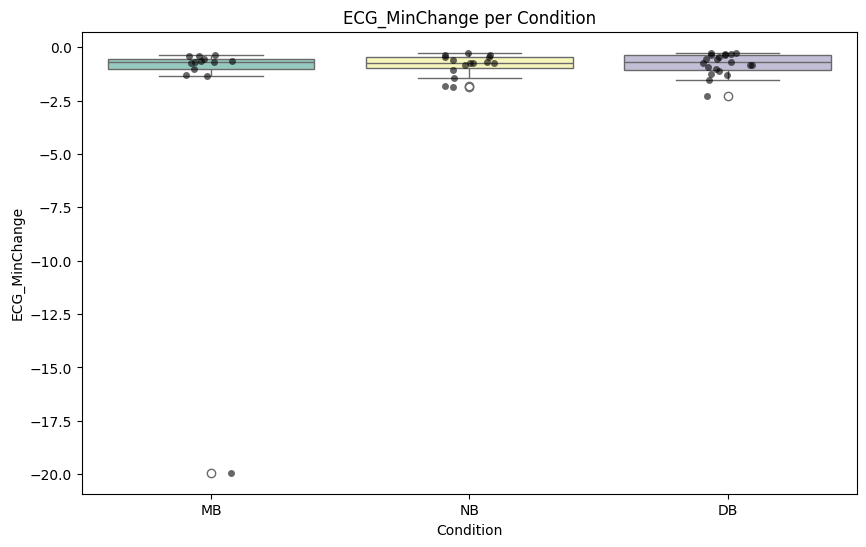

/tmp/ipython-input-2197593764.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ecg_df, x='Condition', y=metric, palette="Set3")


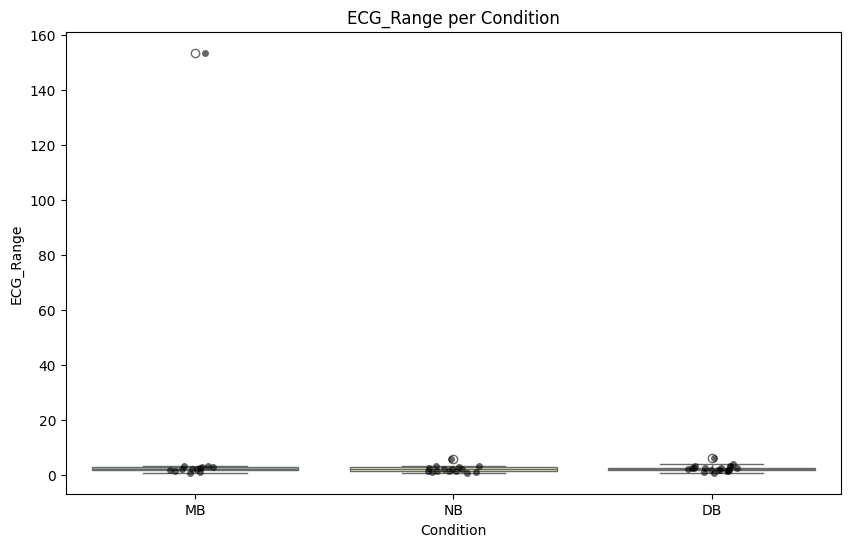

/tmp/ipython-input-2197593764.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ecg_df, x='Condition', y=metric, palette="Set3")


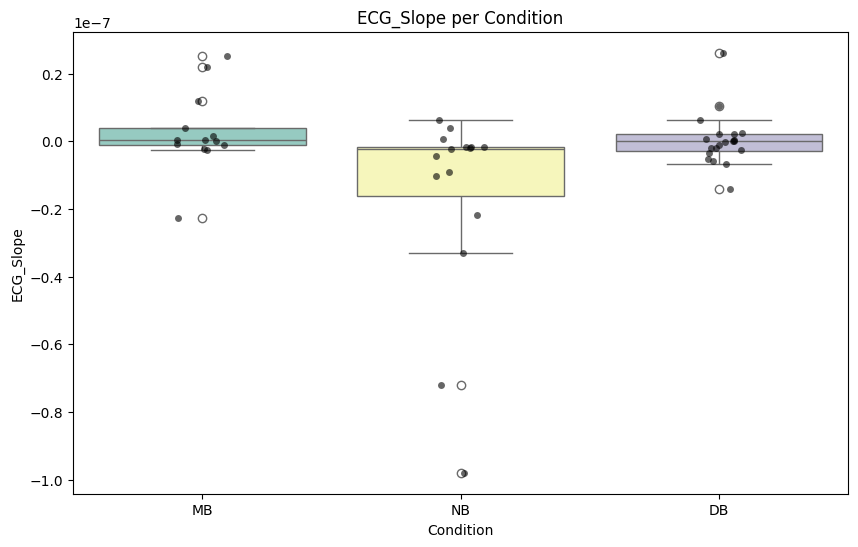

/tmp/ipython-input-2197593764.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ecg_df, x='Condition', y=metric, palette="Set3")


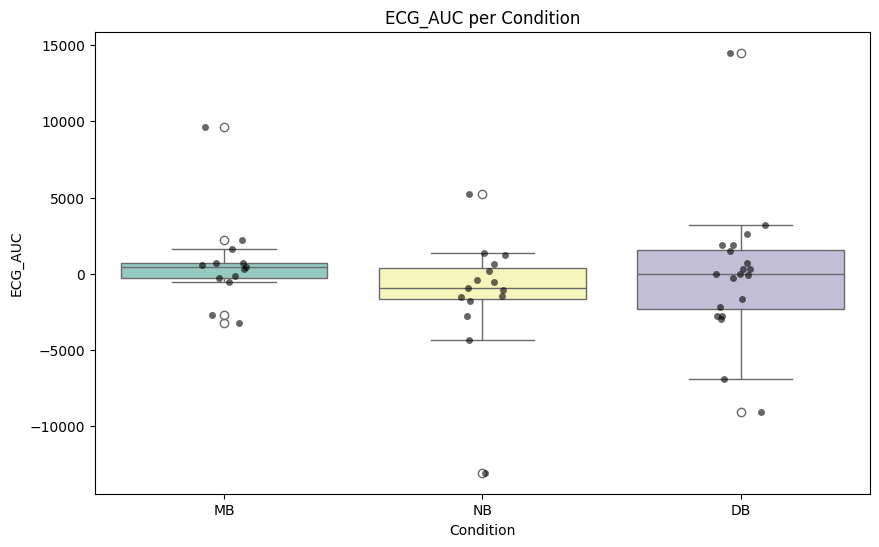

/tmp/ipython-input-2197593764.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ecg_df, x='Condition', y=metric, palette="Set3")


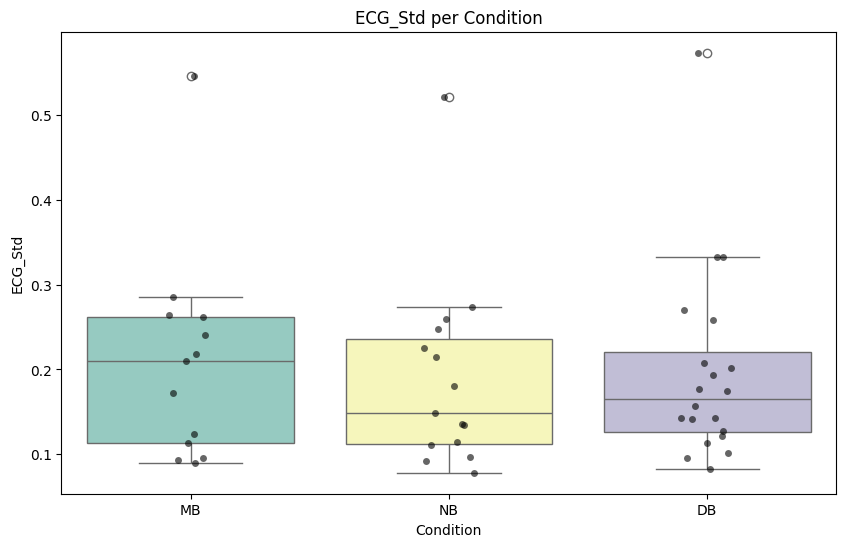


Friedman Test - ECG_MeanChange:
             Source         W  ddof1         Q     p-unc
Friedman  Condition  0.234568      2  4.222222  0.121103

Friedman Test - ECG_PeakChange:
             Source         W  ddof1         Q     p-unc
Friedman  Condition  0.037037      2  0.666667  0.716531

Friedman Test - ECG_MinChange:
             Source         W  ddof1         Q    p-unc
Friedman  Condition  0.049383      2  0.888889  0.64118

Friedman Test - ECG_Range:
             Source        W  ddof1         Q     p-unc
Friedman  Condition  0.08642      2  1.555556  0.459426

Friedman Test - ECG_Slope:
             Source         W  ddof1         Q     p-unc
Friedman  Condition  0.160494      2  2.888889  0.235877

Friedman Test - ECG_AUC:
             Source         W  ddof1         Q     p-unc
Friedman  Condition  0.259259      2  4.666667  0.096972

Friedman Test - ECG_Std:
             Source        W  ddof1         Q     p-unc
Friedman  Condition  0.08642      2  1.555556  0.459426

W

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy.stats import linregress, wilcoxon
from itertools import combinations

# -----------------------------
# Step 1: Compute per-participant per-condition ECG features
# -----------------------------
ecg_features = []

window = 100  # number of samples for baseline/ending averages

for (pid, cond), df in all_data_ecg.groupby(['participant', 'Condition']):
    df_sorted = df.sort_values('Timestamp')
    t = np.arange(len(df_sorted))

    # --- ECG ---
    ecg_baseline = df_sorted['Lead II (LL-LA)'].iloc[:window].mean()
    ecg_end = df_sorted['Lead II (LL-LA)'].iloc[-window:].mean()
    ecg_peak = df_sorted['Lead II (LL-LA)'].max()
    ecg_min = df_sorted['Lead II (LL-LA)'].min()
    ecg_slope = linregress(t, df_sorted['Lead II (LL-LA)']).slope
    ecg_auc = (df_sorted['Lead II (LL-LA)'] - ecg_baseline).sum()
    ecg_std = df_sorted['Lead II (LL-LA)'].std()
    ecg_range = ecg_peak - ecg_min

    ecg_features.append({
        'participant': pid,
        'Condition': cond,
        'ECG_Baseline': ecg_baseline,
        'ECG_End': ecg_end,
        'ECG_MeanChange': ecg_end - ecg_baseline,
        'ECG_PeakChange': ecg_peak - ecg_baseline,
        'ECG_MinChange': ecg_min - ecg_baseline,
        'ECG_Range': ecg_range,
        'ECG_Slope': ecg_slope,
        'ECG_AUC': ecg_auc,
        'ECG_Std': ecg_std,
        'ECG_NormMeanChange': (ecg_end - ecg_baseline)/ecg_baseline if ecg_baseline!=0 else np.nan,
        'ECG_NormPeakChange': (ecg_peak - ecg_baseline)/ecg_baseline if ecg_baseline!=0 else np.nan,
    })

ecg_df = pd.DataFrame(ecg_features)
print(ecg_df.head())

# -----------------------------
# Step 2: Visualize ECG distributions
# -----------------------------
metrics_ecg = [
    "ECG_MeanChange", "ECG_PeakChange", "ECG_MinChange", "ECG_Range", "ECG_Slope", "ECG_AUC", "ECG_Std"
]

for metric in metrics_ecg:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=ecg_df, x='Condition', y=metric, palette="Set3")
    sns.stripplot(data=ecg_df, x='Condition', y=metric, color='black', alpha=0.6)
    plt.title(f"{metric} per Condition")
    plt.show()

# -----------------------------
# Step 3: Friedman Tests
# -----------------------------
results_ecg = {}
for metric in metrics_ecg:
    try:
        friedman = pg.friedman(data=ecg_df, dv=metric, within="Condition", subject="participant")
        results_ecg[metric] = friedman
        print(f"\nFriedman Test - {metric}:")
        print(friedman)
    except Exception as e:
        print(f"Skipping {metric} due to error: {e}")

# -----------------------------
# Step 4: Post-hoc Wilcoxon signed-rank tests
# -----------------------------
wilcoxon_ecg = {}
conditions = ecg_df['Condition'].unique()
pairs = list(combinations(conditions, 2))

for metric in metrics_ecg:
    wilcoxon_ecg[metric] = []
    for cond1, cond2 in pairs:
        df1 = ecg_df[ecg_df['Condition']==cond1].set_index('participant')
        df2 = ecg_df[ecg_df['Condition']==cond2].set_index('participant')
        common_participants = df1.index.intersection(df2.index)
        if len(common_participants) > 0:
            stat, p = wilcoxon(df1.loc[common_participants, metric], df2.loc[common_participants, metric])
            wilcoxon_ecg[metric].append({
                'Condition1': cond1,
                'Condition2': cond2,
                'Statistic': stat,
                'p-value': p
            })

# Display Wilcoxon results
for metric, res in wilcoxon_ecg.items():
    print(f"\nWilcoxon signed-rank tests - {metric}:")
    print(pd.DataFrame(res))


In [ ]:
import pandas as pd
from scipy.stats import wilcoxon
from itertools import combinations

# Step 1: Pivot to wide format
hr_wide = hr_df.pivot(index='participant', columns='Condition', values='HeartRate')
hr_wide.dropna(inplace=True)  # Drop participants with missing data

# Check structure
print(hr_wide.head())

# Step 2: Wilcoxon Signed-Rank Tests for all pairs
conditions = ['MB', 'DB', 'NB']  # your three conditions
results = []

for cond1, cond2 in combinations(conditions, 2):
    # Drop participants with missing data in either condition
    paired_data = hr_wide[[cond1, cond2]].dropna()

    if paired_data.shape[0] < 5:
        print(f"Not enough paired samples for {cond1} vs {cond2}, skipping...")
        continue

    stat, p = wilcoxon(paired_data[cond1], paired_data[cond2])
    results.append({
        'Comparison': f'{cond1} vs {cond2}',
        'Statistic': stat,
        'p-value': p
    })

# Step 3: Show results
wilcoxon_results = pd.DataFrame(results)
print("\nPairwise Wilcoxon Signed-Rank Tests (Heart Rate):\n")
print(wilcoxon_results)


Condition            DB          MB          NB
participant                                    
17            28.634780   45.295843   29.435417
18           153.999766  154.954028  152.537656
21            81.385745   89.173958   90.467928
25            75.743121  110.175462  126.010267
26           134.542124  127.240098  137.332414

Pairwise Wilcoxon Signed-Rank Tests (Heart Rate):

  Comparison  Statistic   p-value
0   MB vs DB       18.0  1.000000
1   MB vs NB       15.0  0.742188
2   DB vs NB       16.0  0.843750


In different condition how does physiological signal change

   participant Condition  GSR_MeanChange  GSR_PeakChange  PPG_MeanChange  \
0            1        DB       -0.002988        0.092890        6.518300   
1            1        MB       -0.000028        0.077624       -5.052225   
2            1        NB       -0.000334        0.104052       -3.536996   
3            2        DB       -0.006623        0.031818       13.288105   
4            2        MB       -0.001010        0.026314       81.303855   

   PPG_PeakChange  
0     1719.507304  
1     1370.511765  
2      971.054156  
3     1062.090727  
4     1321.325908  


/tmp/ipython-input-4014224026.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


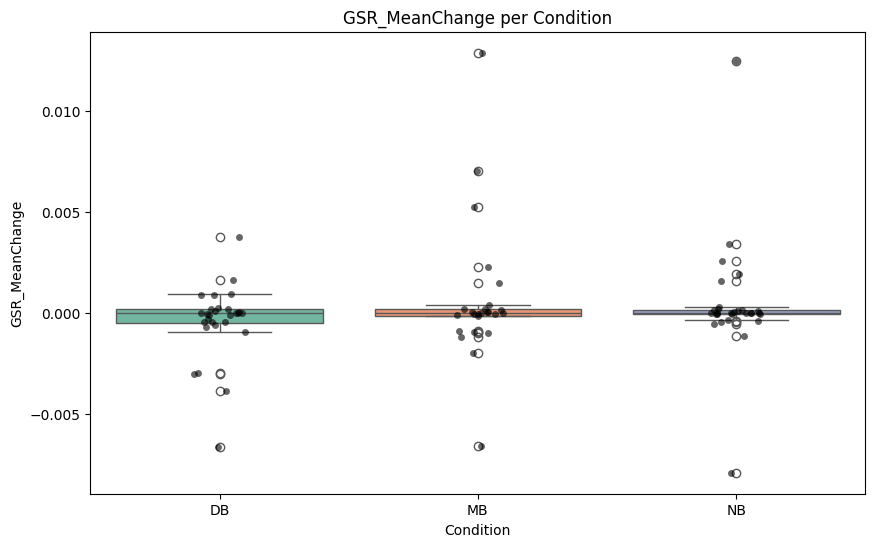

/tmp/ipython-input-4014224026.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


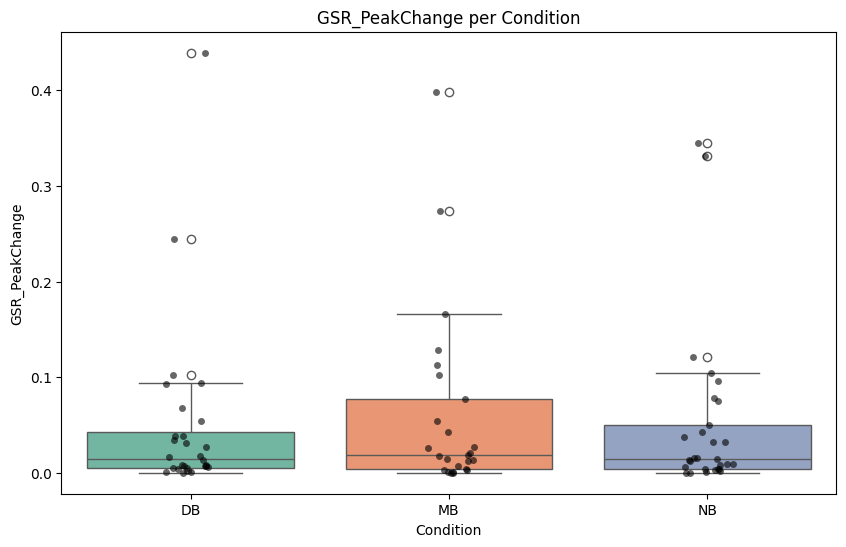

/tmp/ipython-input-4014224026.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


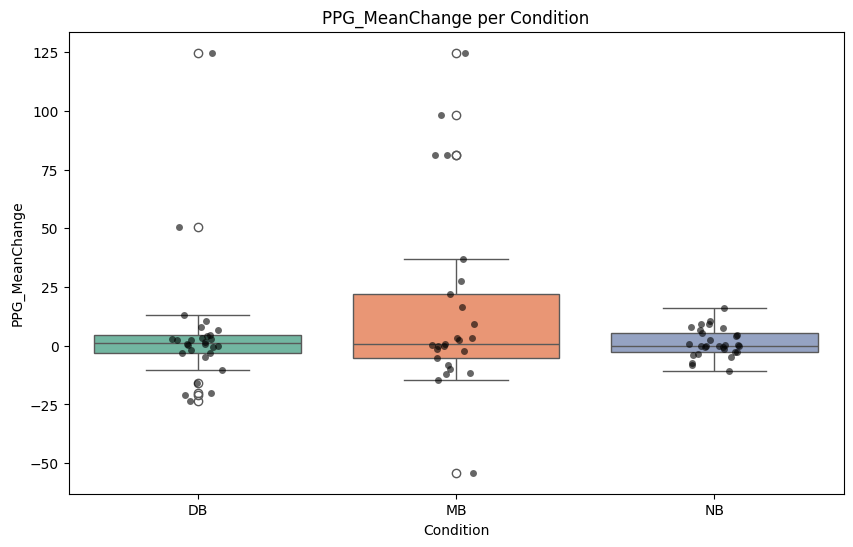

/tmp/ipython-input-4014224026.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


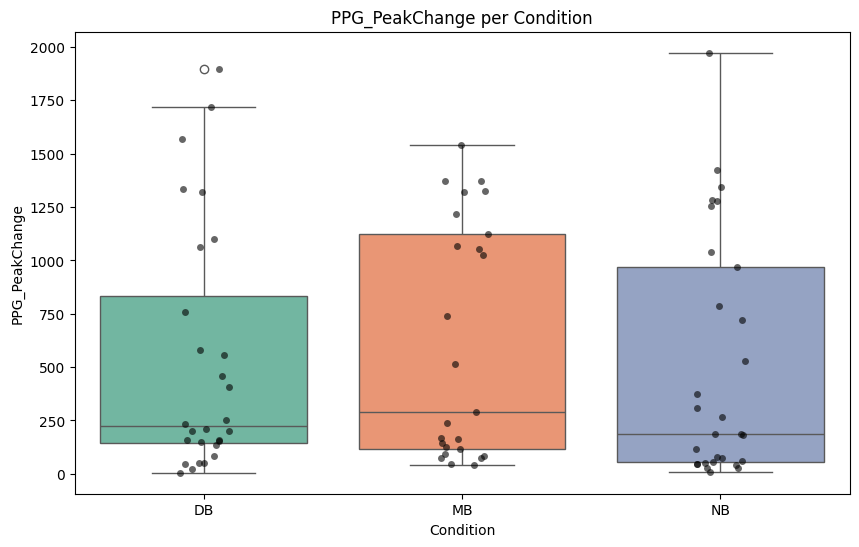


Friedman Test - GSR_MeanChange:
             Source       W  ddof1     Q     p-unc
Friedman  Condition  0.1488      2  7.44  0.024234

Friedman Test - GSR_PeakChange:
             Source       W  ddof1     Q    p-unc
Friedman  Condition  0.0448      2  2.24  0.32628

Friedman Test - PPG_MeanChange:
             Source       W  ddof1     Q    p-unc
Friedman  Condition  0.0048      2  0.24  0.88692

Friedman Test - PPG_PeakChange:
             Source       W  ddof1     Q     p-unc
Friedman  Condition  0.0208      2  1.04  0.594521

Post-hoc Wilcoxon - GSR_MeanChange:
    Contrast   A   B  Paired  Parametric  W-val alternative     p-unc  \
0  Condition  DB  MB    True       False   98.0   two-sided  0.085139   
1  Condition  DB  NB    True       False   89.0   two-sided  0.048262   
2  Condition  MB  NB    True       False  149.0   two-sided  0.730989   

     p-corr p-adjust    hedges  
0  0.255417     bonf -0.391237  
1  0.144787     bonf -0.335505  
2  1.000000     bonf  0.068541  

P

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

# -----------------------------
# Step 1: Compute per-participant per-condition metrics
# -----------------------------
changes = []

window = 100  # number of samples for baseline/ending averages (tune as needed)

for (pid, cond), df in all_data_gsr.groupby(['participant', 'Condition']):
    df_sorted = df.sort_values('Timestamp')  # ensure chronological

    # ---- GSR ----
    gsr_baseline = df_sorted['GSR_Filtered'].iloc[:window].mean()
    gsr_end      = df_sorted['GSR_Filtered'].iloc[-window:].mean()
    gsr_mean_change = gsr_end - gsr_baseline
    gsr_peak_change = df_sorted['GSR_Filtered'].max() - gsr_baseline  # max deviation

    # ---- PPG ----
    ppg_baseline = df_sorted['PPG_Filtered'].iloc[:window].mean()
    ppg_end      = df_sorted['PPG_Filtered'].iloc[-window:].mean()
    ppg_mean_change = ppg_end - ppg_baseline
    ppg_peak_change = df_sorted['PPG_Filtered'].max() - ppg_baseline  # max deviation

    changes.append({
        'participant': pid,
        'Condition': cond,
        'GSR_MeanChange': gsr_mean_change,
        'GSR_PeakChange': gsr_peak_change,
        'PPG_MeanChange': ppg_mean_change,
        'PPG_PeakChange': ppg_peak_change
    })

changes_df = pd.DataFrame(changes)
print(changes_df.head())

# -----------------------------
# Step 2: Visualize
# -----------------------------
for metric in ["GSR_MeanChange", "GSR_PeakChange", "PPG_MeanChange", "PPG_PeakChange"]:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")
    sns.stripplot(data=changes_df, x='Condition', y=metric, color='black', alpha=0.6)
    plt.title(f"{metric} per Condition")
    plt.show()

# -----------------------------
# Step 3: Friedman Tests
# -----------------------------
results = {}
for metric in ["GSR_MeanChange", "GSR_PeakChange", "PPG_MeanChange", "PPG_PeakChange"]:
    friedman = pg.friedman(data=changes_df, dv=metric, within="Condition", subject="participant")
    results[metric] = friedman
    print(f"\nFriedman Test - {metric}:")
    print(friedman)

# -----------------------------
# Step 4: Post-hoc pairwise Wilcoxon if significant
# -----------------------------
posthocs = {}
for metric in ["GSR_MeanChange", "GSR_PeakChange", "PPG_MeanChange", "PPG_PeakChange"]:
    posthoc = pg.pairwise_tests(data=changes_df, dv=metric, within="Condition",
                                subject="participant", parametric=False, padjust="bonf")
    posthocs[metric] = posthoc
    print(f"\nPost-hoc Wilcoxon - {metric}:")
    print(posthoc)


   participant Condition  GSR_Baseline   GSR_End  GSR_MeanChange  \
0            1        DB      0.002966 -0.000022       -0.002988   
1            1        MB      0.000040  0.000013       -0.000028   
2            1        NB      0.000418  0.000084       -0.000334   
3            2        DB      0.000283 -0.006340       -0.006623   
4            2        MB     -0.000579 -0.001589       -0.001010   

   GSR_PeakChange  GSR_MinChange  GSR_Range     GSR_Slope    GSR_AUC  ...  \
0        0.092890      -0.098988   0.191879 -5.194340e-08 -18.046167  ...   
1        0.077624      -0.105352   0.182976 -5.432541e-10  -0.242327  ...   
2        0.104052      -0.139101   0.243153 -5.508487e-09  -2.519631  ...   
3        0.031818      -0.043987   0.075805 -1.504606e-08  -3.598937  ...   
4        0.026314      -0.038383   0.064696 -9.467064e-11  13.329834  ...   

     PPG_End  PPG_MeanChange  PPG_PeakChange  PPG_MinChange    PPG_Range  \
0   1.279600        6.518300     1719.507304   -1687

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


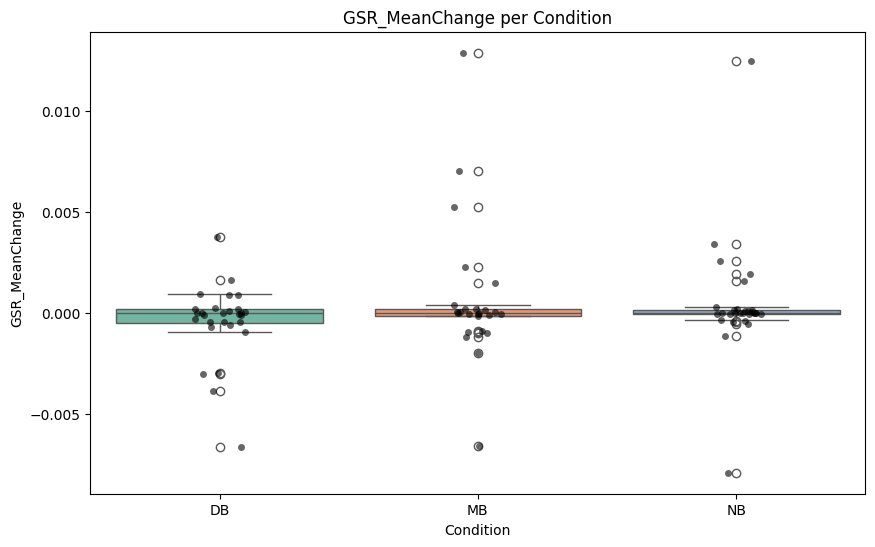

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


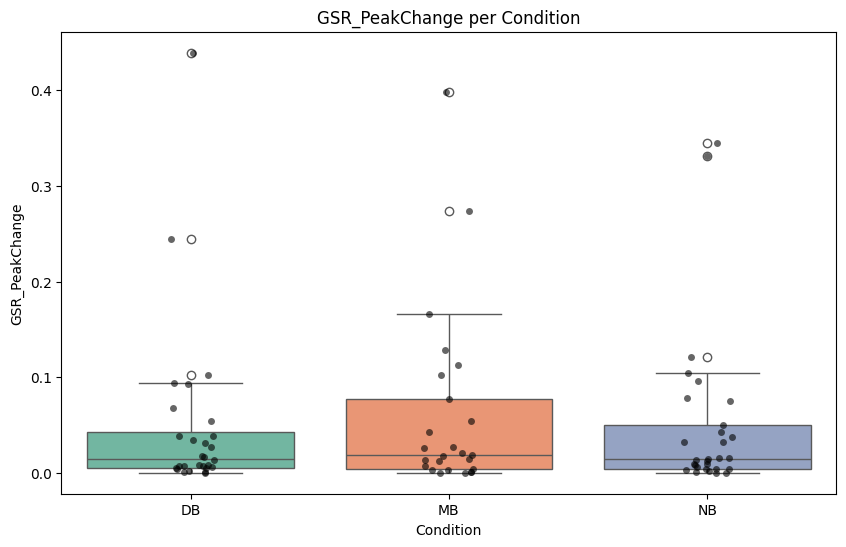

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


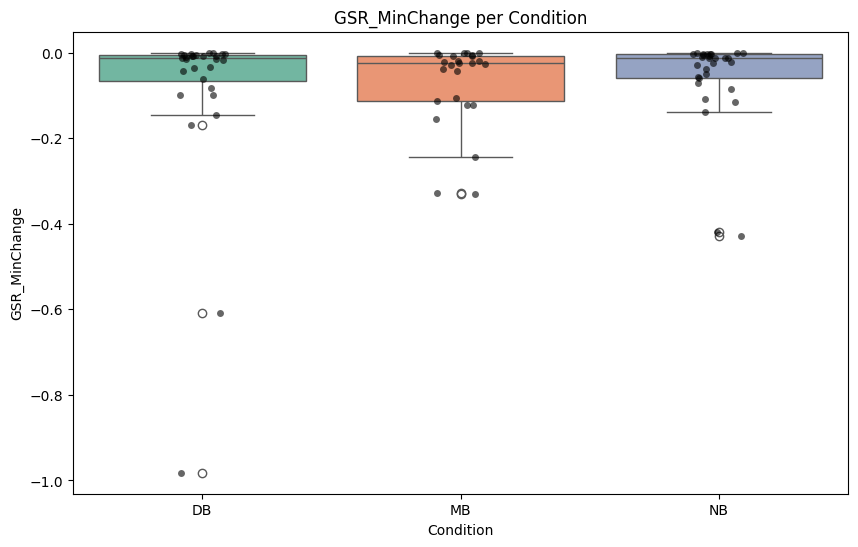

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


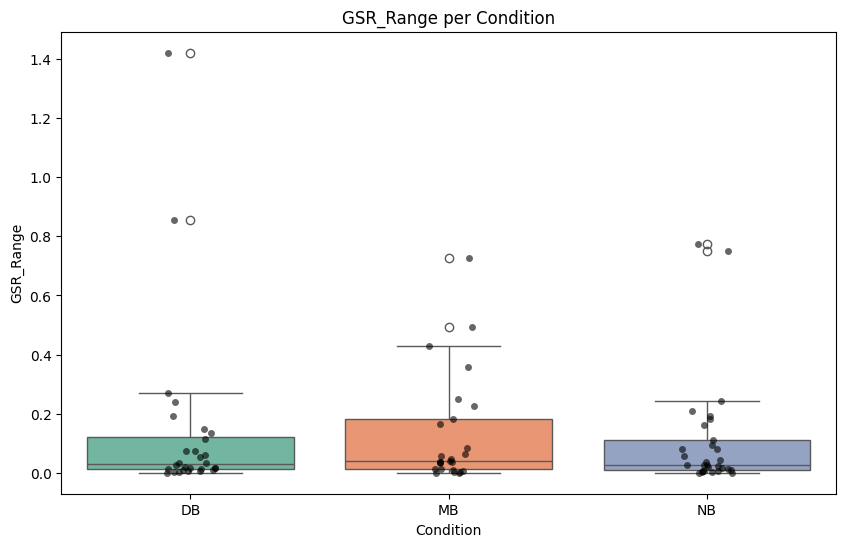

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


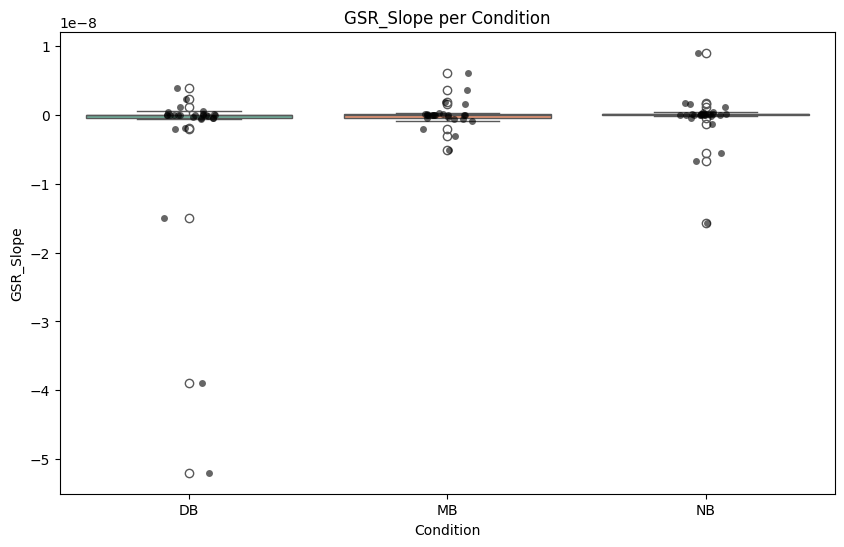

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


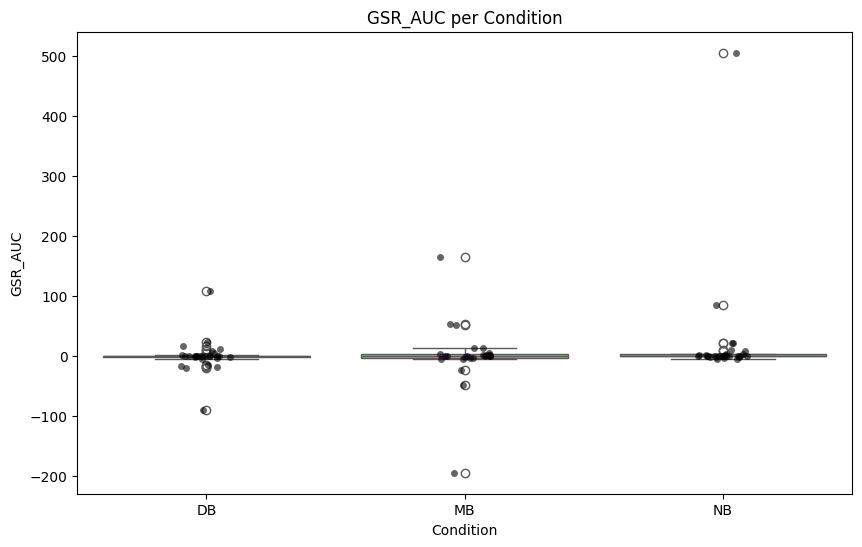

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


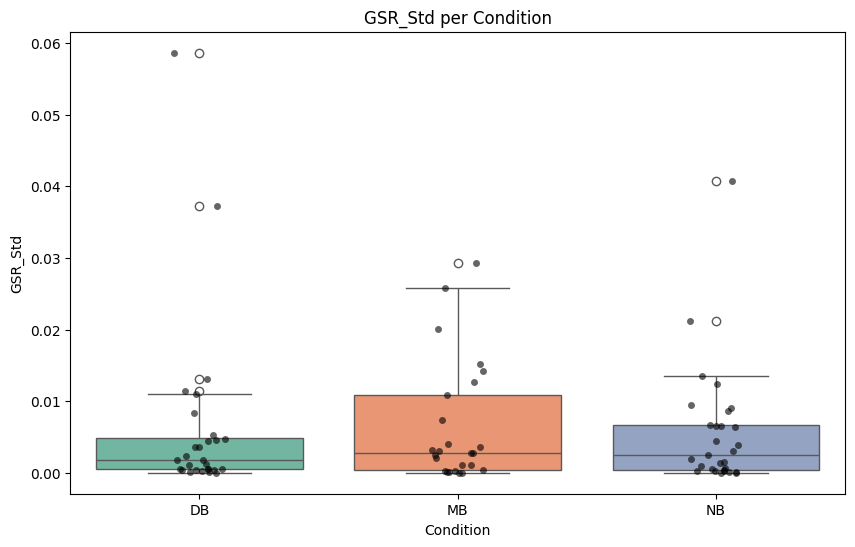

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


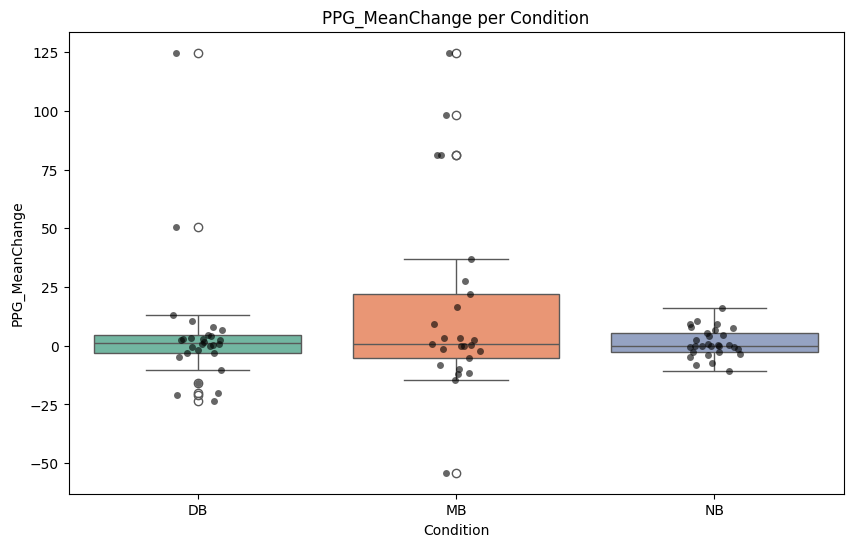

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


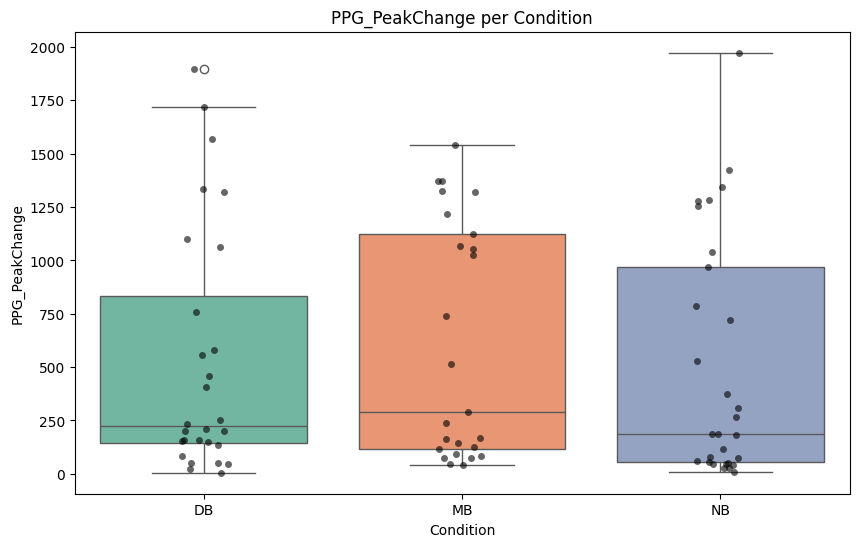

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


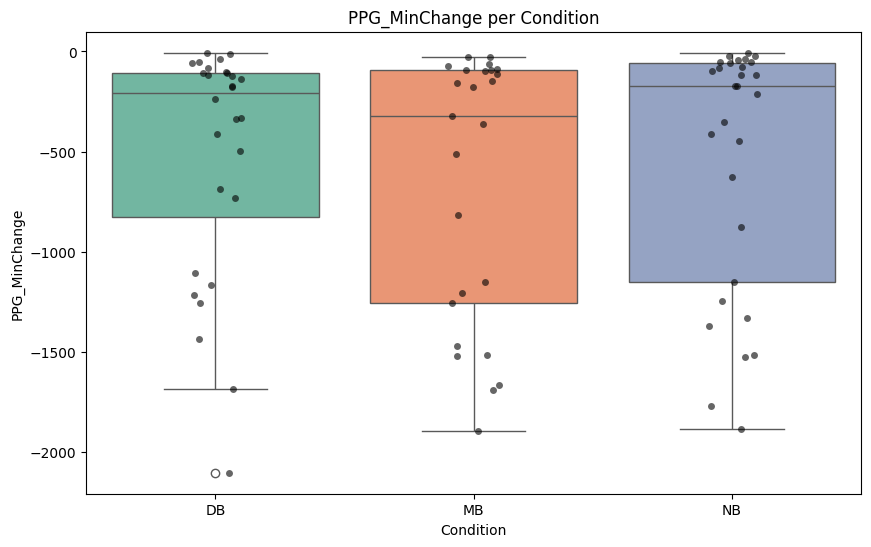

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


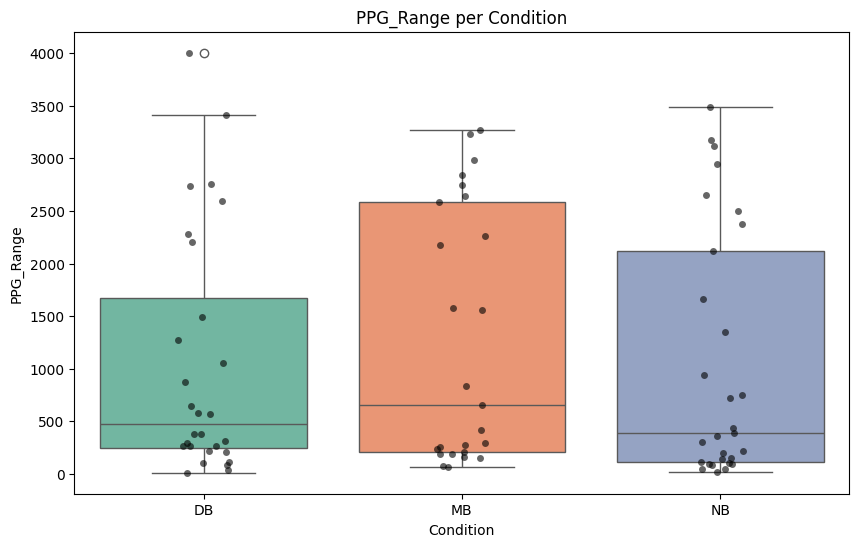

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


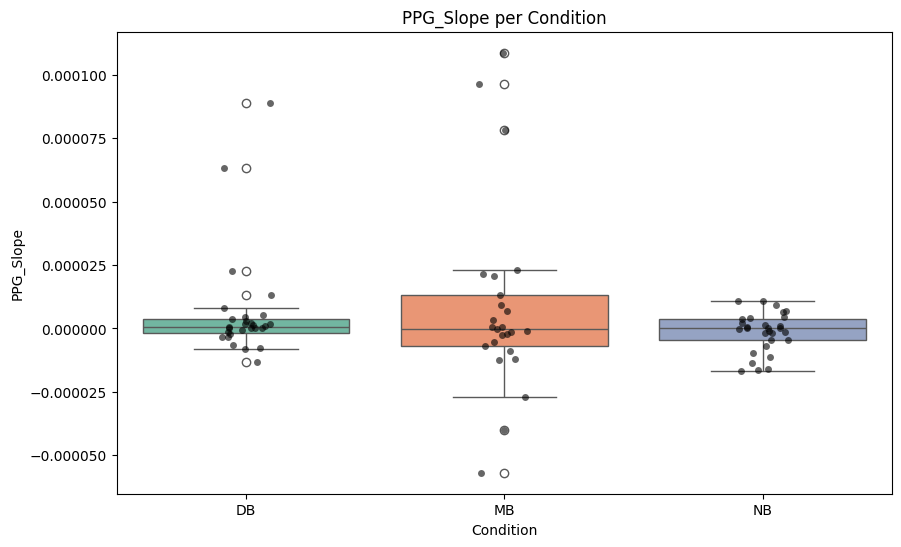

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


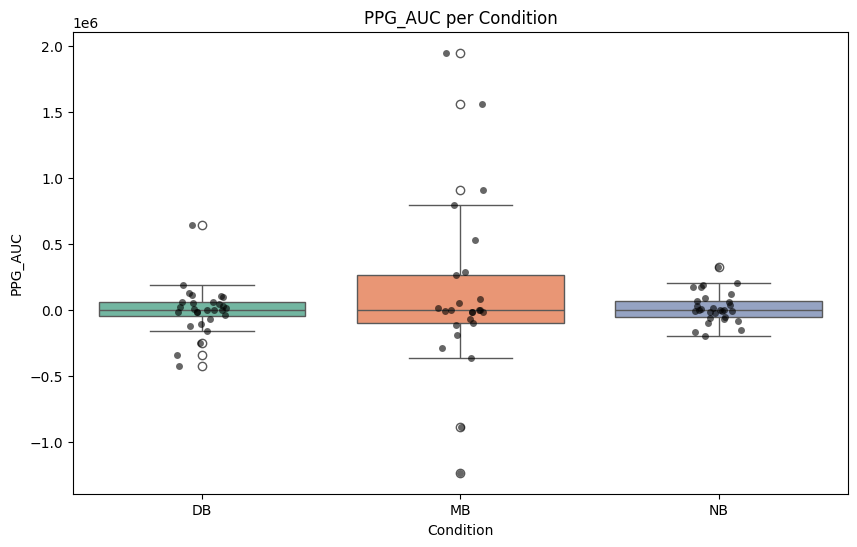

/tmp/ipython-input-2768644178.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")


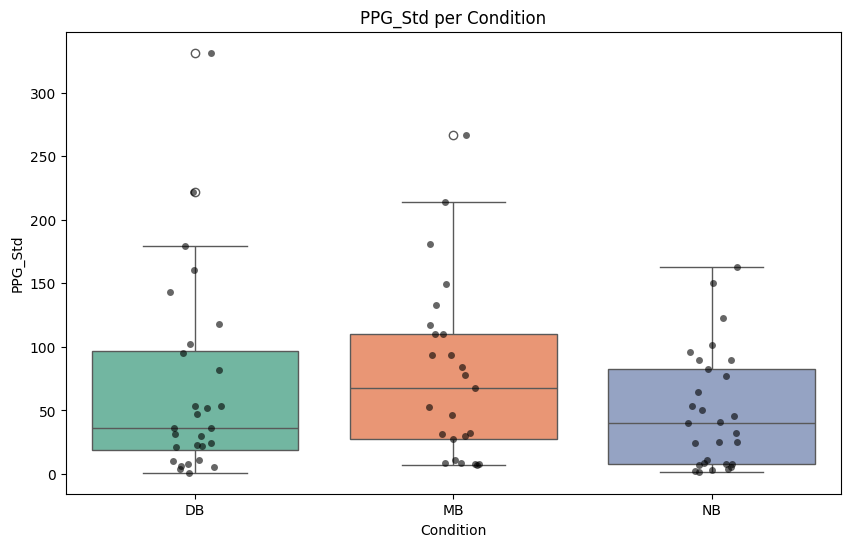


Friedman Test - GSR_MeanChange:
             Source       W  ddof1     Q     p-unc
Friedman  Condition  0.1488      2  7.44  0.024234

Friedman Test - GSR_PeakChange:
             Source       W  ddof1     Q    p-unc
Friedman  Condition  0.0448      2  2.24  0.32628

Friedman Test - GSR_MinChange:
             Source       W  ddof1     Q     p-unc
Friedman  Condition  0.0112      2  0.56  0.755784

Friedman Test - GSR_Range:
             Source       W  ddof1     Q    p-unc
Friedman  Condition  0.0048      2  0.24  0.88692

Friedman Test - GSR_Slope:
             Source       W  ddof1     Q     p-unc
Friedman  Condition  0.0496      2  2.48  0.289384

Friedman Test - GSR_AUC:
             Source       W  ddof1     Q     p-unc
Friedman  Condition  0.0912      2  4.56  0.102284

Friedman Test - GSR_Std:
             Source       W  ddof1     Q     p-unc
Friedman  Condition  0.0192      2  0.96  0.618783

Friedman Test - PPG_MeanChange:
             Source       W  ddof1     Q    p-unc
F

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy.stats import linregress, wilcoxon
from itertools import combinations

# -----------------------------
# Step 1: Compute per-participant per-condition metrics
# -----------------------------
changes = []

window = 100  # number of samples for baseline/ending averages

for (pid, cond), df in all_data_gsr.groupby(['participant', 'Condition']):
    df_sorted = df.sort_values('Timestamp')
    t = np.arange(len(df_sorted))

    # --- GSR ---
    gsr_baseline = df_sorted['GSR_Filtered'].iloc[:window].mean()
    gsr_end = df_sorted['GSR_Filtered'].iloc[-window:].mean()
    gsr_peak = df_sorted['GSR_Filtered'].max()
    gsr_min = df_sorted['GSR_Filtered'].min()
    gsr_slope = linregress(t, df_sorted['GSR_Filtered']).slope
    gsr_auc = (df_sorted['GSR_Filtered'] - gsr_baseline).sum()
    gsr_std = df_sorted['GSR_Filtered'].std()
    gsr_range = gsr_peak - gsr_min

    # --- PPG ---
    ppg_baseline = df_sorted['PPG_Filtered'].iloc[:window].mean()
    ppg_end = df_sorted['PPG_Filtered'].iloc[-window:].mean()
    ppg_peak = df_sorted['PPG_Filtered'].max()
    ppg_min = df_sorted['PPG_Filtered'].min()
    ppg_slope = linregress(t, df_sorted['PPG_Filtered']).slope
    ppg_auc = (df_sorted['PPG_Filtered'] - ppg_baseline).sum()
    ppg_std = df_sorted['PPG_Filtered'].std()
    ppg_range = ppg_peak - ppg_min

    changes.append({
        'participant': pid,
        'Condition': cond,
        # GSR Features
        'GSR_Baseline': gsr_baseline,
        'GSR_End': gsr_end,
        'GSR_MeanChange': gsr_end - gsr_baseline,
        'GSR_PeakChange': gsr_peak - gsr_baseline,
        'GSR_MinChange': gsr_min - gsr_baseline,
        'GSR_Range': gsr_range,
        'GSR_Slope': gsr_slope,
        'GSR_AUC': gsr_auc,
        'GSR_Std': gsr_std,
        'GSR_NormMeanChange': (gsr_end - gsr_baseline)/gsr_baseline if gsr_baseline!=0 else np.nan,
        'GSR_NormPeakChange': (gsr_peak - gsr_baseline)/gsr_baseline if gsr_baseline!=0 else np.nan,
        # PPG Features
        'PPG_Baseline': ppg_baseline,
        'PPG_End': ppg_end,
        'PPG_MeanChange': ppg_end - ppg_baseline,
        'PPG_PeakChange': ppg_peak - ppg_baseline,
        'PPG_MinChange': ppg_min - ppg_baseline,
        'PPG_Range': ppg_range,
        'PPG_Slope': ppg_slope,
        'PPG_AUC': ppg_auc,
        'PPG_Std': ppg_std,
        'PPG_NormMeanChange': (ppg_end - ppg_baseline)/ppg_baseline if ppg_baseline!=0 else np.nan,
        'PPG_NormPeakChange': (ppg_peak - ppg_baseline)/ppg_baseline if ppg_baseline!=0 else np.nan,
    })

changes_df = pd.DataFrame(changes)
print(changes_df.head())

# -----------------------------
# Step 2: Visualize distributions
# -----------------------------
metrics_to_plot = [
    "GSR_MeanChange", "GSR_PeakChange", "GSR_MinChange", "GSR_Range", "GSR_Slope", "GSR_AUC", "GSR_Std",
    "PPG_MeanChange", "PPG_PeakChange", "PPG_MinChange", "PPG_Range", "PPG_Slope", "PPG_AUC", "PPG_Std"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=changes_df, x='Condition', y=metric, palette="Set2")
    sns.stripplot(data=changes_df, x='Condition', y=metric, color='black', alpha=0.6)
    plt.title(f"{metric} per Condition")
    plt.show()

# -----------------------------
# Step 3: Friedman Tests
# -----------------------------
results = {}
for metric in metrics_to_plot:
    try:
        friedman = pg.friedman(data=changes_df, dv=metric, within="Condition", subject="participant")
        results[metric] = friedman
        print(f"\nFriedman Test - {metric}:")
        print(friedman)
    except Exception as e:
        print(f"Skipping {metric} due to error: {e}")

# -----------------------------
# Step 4: Post-hoc pairwise Wilcoxon tests (paired)
# -----------------------------
wilcoxon_results = {}

conditions = changes_df['Condition'].unique()
pairs = list(combinations(conditions, 2))

for metric in metrics_to_plot:
    wilcoxon_results[metric] = []
    for cond1, cond2 in pairs:
        df1 = changes_df[changes_df['Condition'] == cond1].set_index('participant')
        df2 = changes_df[changes_df['Condition'] == cond2].set_index('participant')
        common_participants = df1.index.intersection(df2.index)
        if len(common_participants) > 0:
            stat, p = wilcoxon(df1.loc[common_participants, metric], df2.loc[common_participants, metric])
            wilcoxon_results[metric].append({
                'Condition1': cond1,
                'Condition2': cond2,
                'Statistic': stat,
                'p-value': p
            })

# Display Wilcoxon results
for metric, res in wilcoxon_results.items():
    print(f"\nWilcoxon signed-rank tests - {metric}:")
    print(pd.DataFrame(res))


eye tracking data

In [ ]:
train_eye_data1

,timestamp,LeftEye_Openness_Openness,RightEye_Openness_Openness,LeftEye_PupilDilation_PupilDilation,RightEye_PupilDilation_PupilDilation,LeftEye_PupilPosition_X,LeftEye_PupilPosition_Y,RightEye_PupilPosition_X,RightEye_PupilPosition_Y,LeftEye_Gaze_X,LeftEye_Gaze_Y,LeftEye_Gaze_Z,RightEye_Gaze_X,RightEye_Gaze_Y,RightEye_Gaze_Z,FMS,Condition,participant
0,2025-04-04 16:56:04.970,1,1,-1.000000,3.022568,-1.000000,-1.000000,0.492361,0.516995,0.000000,0.000000,0.000000,-0.037094,-0.224747,0.973709,4.0,NB,1
1,2025-04-04 16:56:04.979,1,1,-1.000000,3.022568,-1.000000,-1.000000,0.492361,0.516995,0.000000,0.000000,0.000000,-0.037094,-0.224747,0.973709,4.0,NB,1
2,2025-04-04 16:56:04.987,1,1,-1.000000,3.022568,-1.000000,-1.000000,0.492361,0.516995,0.000000,0.000000,0.000000,-0.037094,-0.224747,0.973709,4.0,NB,1
3,2025-04-04 16:56:04.997,1,1,3.128174,3.084106,0.418376,0.583854,0.497622,0.510931,-0.041992,-0.187256,0.981399,-0.066895,-0.199417,0.977615,4.0,NB,1
4,2025-04-04 16:56:05.006,1,1,3.128174,3.084106,0.418376,0.583854,0.497622,0.510931,-0.041992,-0.187256,0.981399,-0.066895,-0.199417,0.977615,4.0,NB,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923446,2025-05-13 14:10:36.609,1,1,3.389496,2.670807,0.492990,0.528666,0.422363,0.509280,-0.012970,-0.166184,0.986008,-0.204178,-0.225769,0.952530,5.0,MB,15
923447,2025-05-13 14:10:36.617,1,1,3.389496,2.670807,0.492990,0.528666,0.422363,0.509280,-0.012970,-0.166184,0.986008,-0.204178,-0.225769,0.952530,5.0,MB,15
923448,2025-05-13 14:10:36.625,1,1,3.478302,2.627075,0.493156,0.527782,0.422265,0.509005,-0.017029,-0.161316,0.986740,-0.205078,-0.223556,0.952866,5.0,MB,15
923449,2025-05-13 14:10:36.633,1,1,3.478302,2.627075,0.493156,0.527782,0.422265,0.509005,-0.017029,-0.161316,0.986740,-0.205078,-0.223556,0.952866,5.0,MB,15


/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


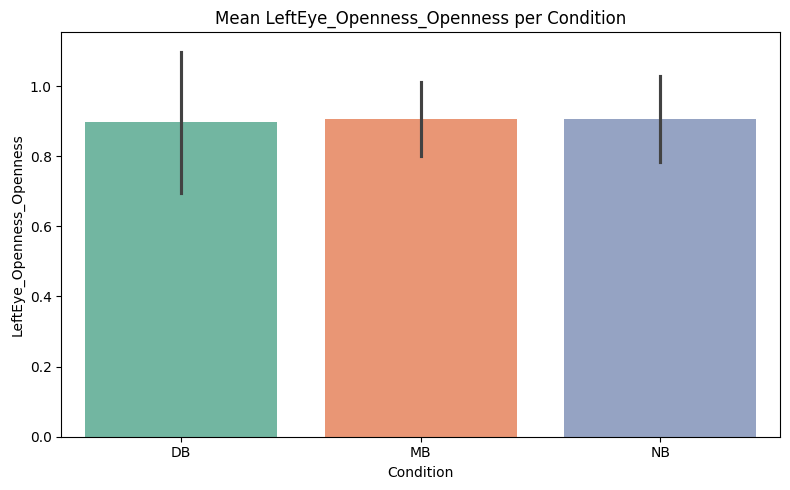

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


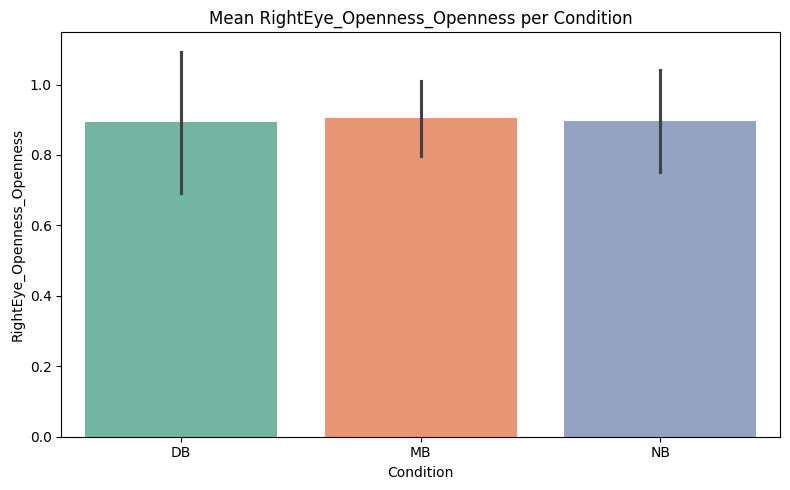

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


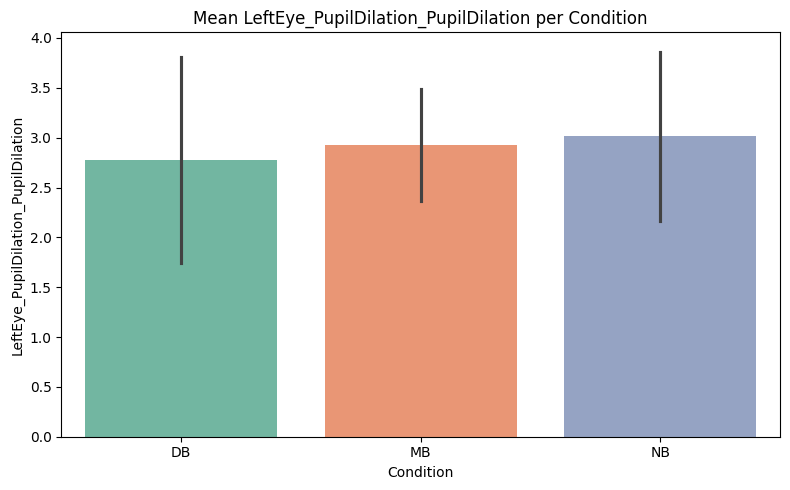

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


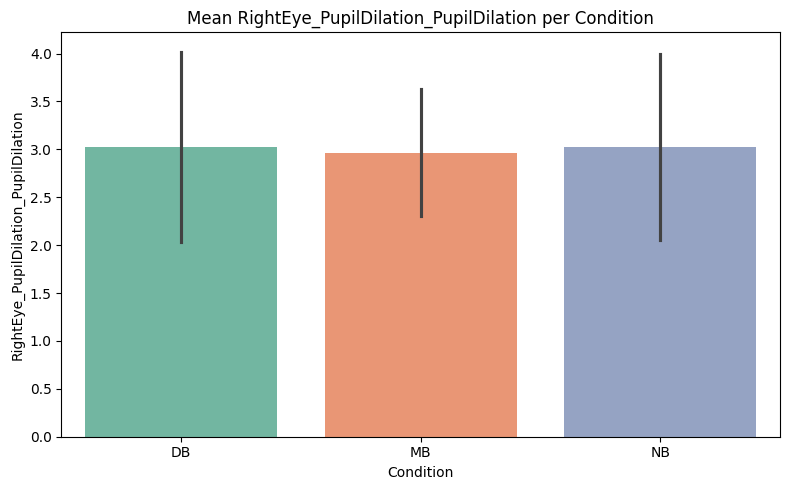

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


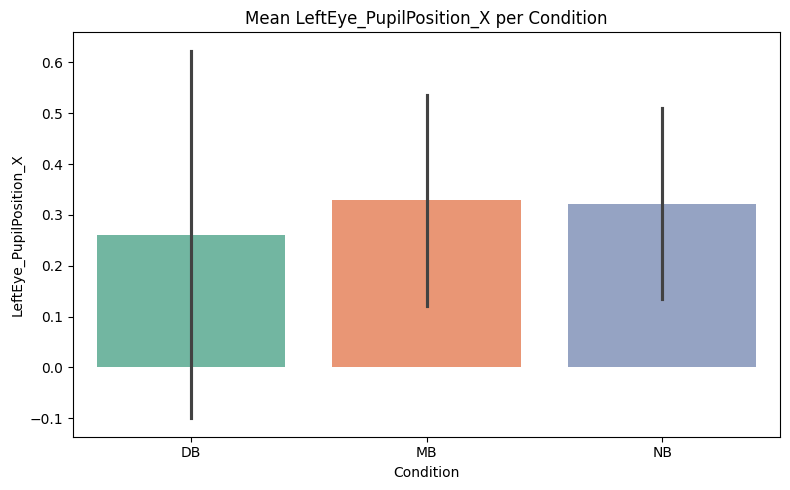

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


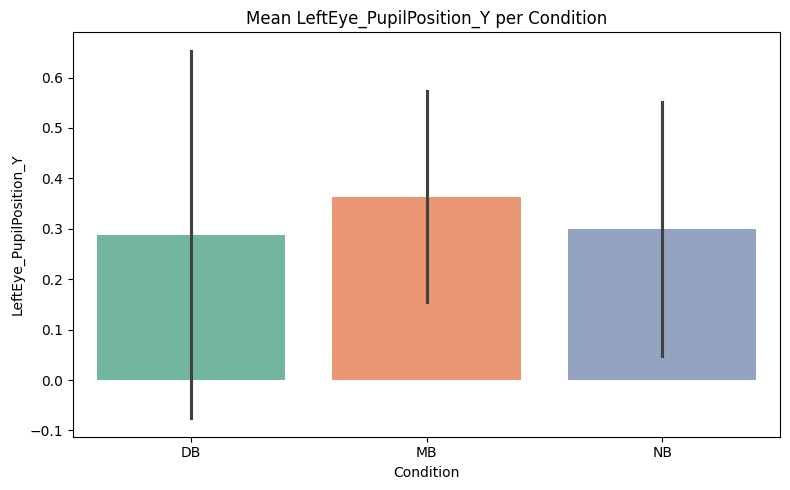

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


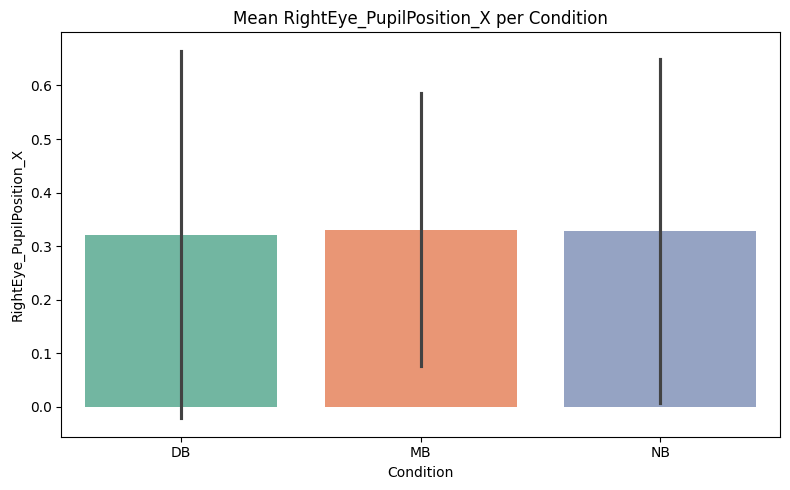

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


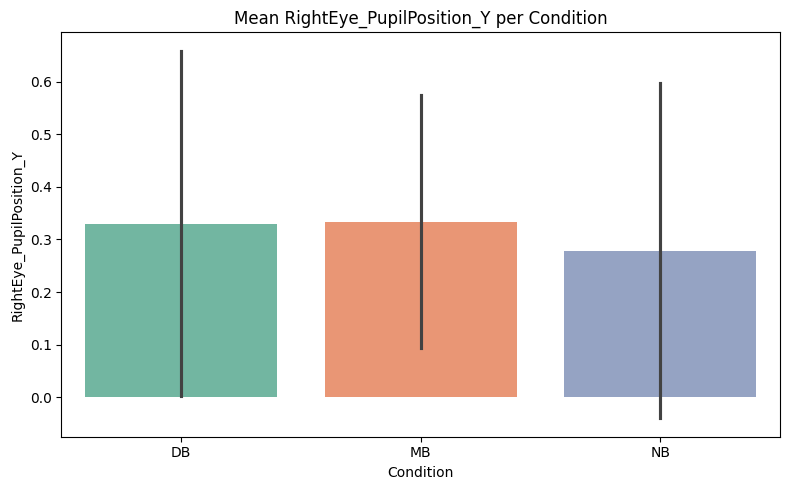

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


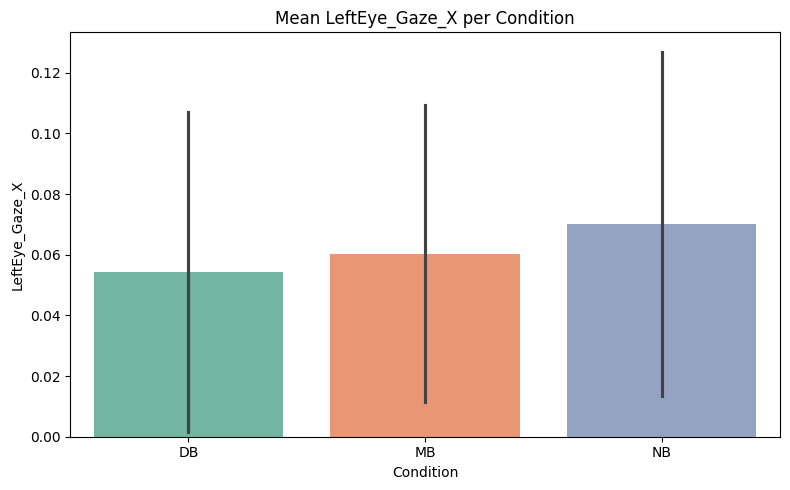

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


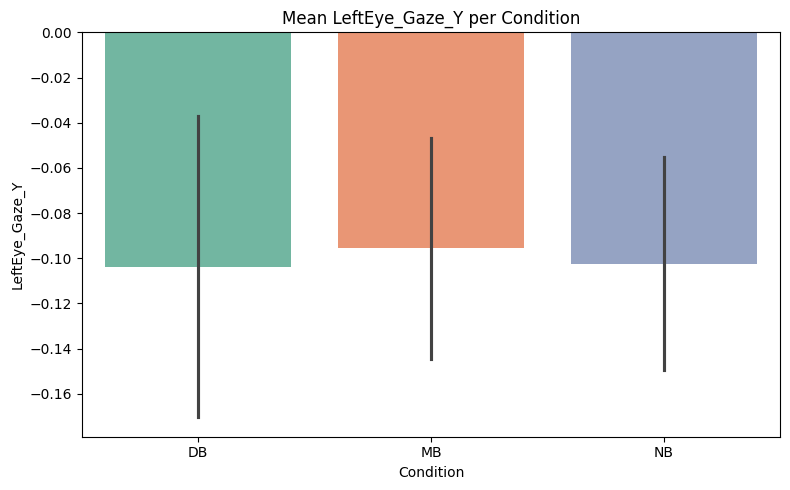

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


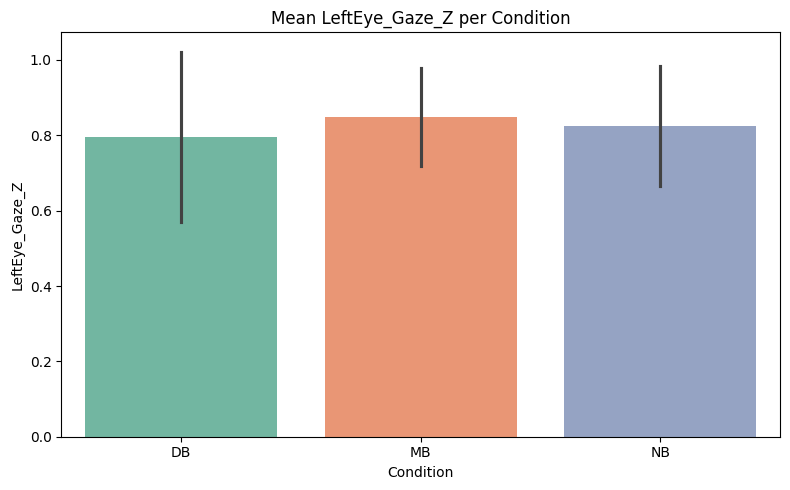

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


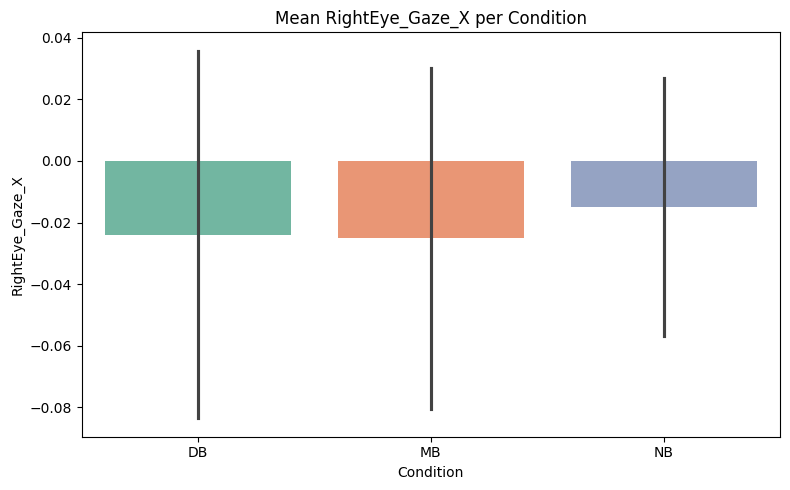

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


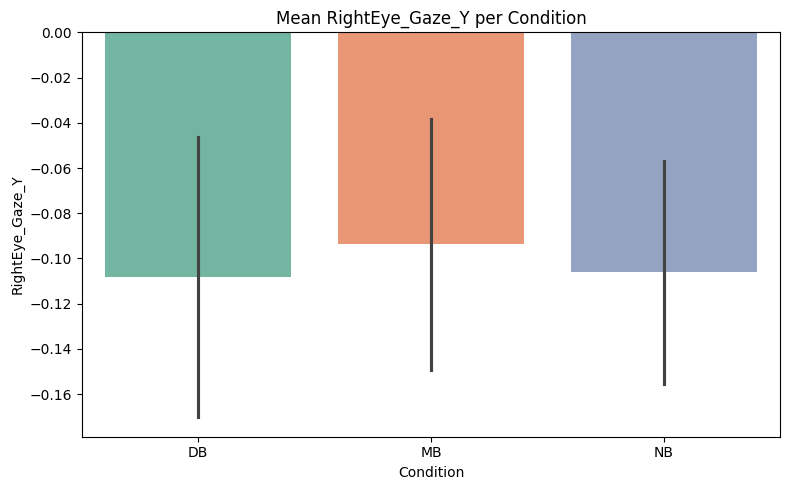

/tmp/ipython-input-2654583176.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
/tmp/ipython-input-2654583176.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')


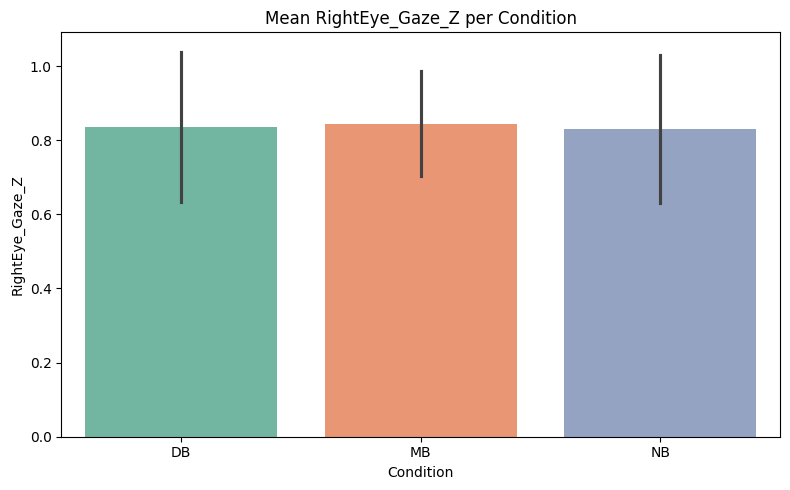


🔬 Wilcoxon Signed-Rank Test Results:
                                 Feature Comparison  Statistic   p-value  \
25                        LeftEye_Gaze_X   MB vs NB       35.0  0.168823   
24                        LeftEye_Gaze_X   MB vs DB       59.0  0.977966   
26                        LeftEye_Gaze_X   DB vs NB       25.0  0.047913   
27                        LeftEye_Gaze_Y   MB vs DB       42.0  0.330261   
28                        LeftEye_Gaze_Y   MB vs NB       50.0  0.599487   
29                        LeftEye_Gaze_Y   DB vs NB       51.0  0.638672   
30                        LeftEye_Gaze_Z   MB vs DB       42.0  0.330261   
31                        LeftEye_Gaze_Z   MB vs NB       60.0  1.000000   
32                        LeftEye_Gaze_Z   DB vs NB       49.0  0.561401   
0              LeftEye_Openness_Openness   MB vs DB       42.0  0.330261   
1              LeftEye_Openness_Openness   MB vs NB       49.0  0.561401   
2              LeftEye_Openness_Openness   DB vs N

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from itertools import combinations

eye_df = train_eye_data1.copy()

# -----------------------------
# Step 1: Prepare data for analysis
# -----------------------------
features = [col for col in eye_df.columns if col not in ['timestamp', 'Condition', 'participant','FMS']]

# Compute mean per participant × condition
summary = eye_df.groupby(['participant', 'Condition'])[features].mean().reset_index()

# -----------------------------
# Step 2: Plot mean values per condition for each feature
# -----------------------------
for feature in features:
    plt.figure(figsize=(8,5))
    sns.barplot(data=summary, x='Condition', y=feature, errorbar='se', palette='Set2', ci='sd')
    plt.title(f'Mean {feature} per Condition')
    plt.ylabel(feature)
    plt.xlabel('Condition')
    plt.tight_layout()
    plt.show()

# -----------------------------
# Step 3: Wilcoxon signed-rank tests between conditions (MB, DB, NB)
# -----------------------------
# Pivot to wide format per feature for each participant
conditions = ['MB', 'DB', 'NB']
results = []

for feature in features:
    wide = summary.pivot(index='participant', columns='Condition', values=feature)

    for cond1, cond2 in combinations(conditions, 2):
        # Drop NaNs (e.g. if data missing for some participants)
        paired = wide[[cond1, cond2]].dropna()

        if paired.shape[0] < 5:
            continue  # Skip if not enough paired samples

        try:
            stat, p = wilcoxon(paired[cond1], paired[cond2])
            results.append({
                'Feature': feature,
                'Comparison': f'{cond1} vs {cond2}',
                'Statistic': stat,
                'p-value': p
            })
        except Exception as e:
            print(f"Error in {feature} ({cond1} vs {cond2}): {e}")


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress, wilcoxon
from itertools import combinations

eye_df = train_eye_data1.copy()

# -----------------------------
# Step 1: Define features to compute per participant × condition
# -----------------------------
cols_to_process = [col for col in eye_df.columns if col not in ['timestamp', 'Condition', 'participant','FMS']]
window = 100  # first/last samples for baseline/end

computed_features = []

for (pid, cond), df in eye_df.groupby(['participant', 'Condition']):
    df_sorted = df.sort_values('timestamp')
    t = np.arange(len(df_sorted))

    feature_dict = {'participant': pid, 'Condition': cond}

    for col in cols_to_process:
        baseline = df_sorted[col].iloc[:window].mean()
        end = df_sorted[col].iloc[-window:].mean()
        peak = df_sorted[col].max()
        min_val = df_sorted[col].min()
        slope = linregress(t, df_sorted[col]).slope
        auc = (df_sorted[col] - baseline).sum()
        std = df_sorted[col].std()
        rng = peak - min_val

        feature_dict.update({
            f'{col}_Baseline': baseline,
            f'{col}_End': end,
            f'{col}_MeanChange': end - baseline,
            f'{col}_PeakChange': peak - baseline,
            f'{col}_MinChange': min_val - baseline,
            f'{col}_Range': rng,
            f'{col}_Slope': slope,
            f'{col}_AUC': auc,
            f'{col}_Std': std,
            f'{col}_NormMeanChange': (end - baseline)/baseline if baseline != 0 else np.nan,
            f'{col}_NormPeakChange': (peak - baseline)/baseline if baseline != 0 else np.nan
        })

    computed_features.append(feature_dict)

eye_features_df = pd.DataFrame(computed_features)
print(eye_features_df.head())

# -----------------------------
# Step 2: Wilcoxon signed-rank tests for all computed features
# -----------------------------
conditions = ['MB', 'DB', 'NB']
pairs = list(combinations(conditions, 2))
all_feature_cols = [c for c in eye_features_df.columns if c not in ['participant', 'Condition']]

wilcoxon_results = []

for feature in all_feature_cols:
    wide = eye_features_df.pivot(index='participant', columns='Condition', values=feature)
    for cond1, cond2 in pairs:
        paired = wide[[cond1, cond2]].dropna()
        if paired.shape[0] < 5:
            continue
        try:
            stat, p = wilcoxon(paired[cond1], paired[cond2])
            wilcoxon_results.append({
                'Feature': feature,
                'Comparison': f'{cond1} vs {cond2}',
                'Statistic': stat,
                'p-value': p
            })
        except Exception as e:
            print(f"Error in {feature} ({cond1} vs {cond2}): {e}")

wilcoxon_results_df = pd.DataFrame(wilcoxon_results)
print(wilcoxon_results_df)


   participant Condition  LeftEye_Openness_Openness_Baseline  \
0            1        DB                                 1.0   
1            1        MB                                 1.0   
2            1        NB                                 1.0   
3            2        DB                                 1.0   
4            2        MB                                 1.0   

   LeftEye_Openness_Openness_End  LeftEye_Openness_Openness_MeanChange  \
0                           0.23                                 -0.77   
1                           1.00                                  0.00   
2                           1.00                                  0.00   
3                           1.00                                  0.00   
4                           1.00                                  0.00   

   LeftEye_Openness_Openness_PeakChange  LeftEye_Openness_Openness_MinChange  \
0                                   0.0                                 -1.0   
1         

/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


                                Feature Comparison  Statistic   p-value
0    LeftEye_Openness_Openness_Baseline   MB vs DB        0.0  0.317311
1    LeftEye_Openness_Openness_Baseline   MB vs NB        1.0  0.654721
2    LeftEye_Openness_Openness_Baseline   DB vs NB        0.0  0.317311
3         LeftEye_Openness_Openness_End   MB vs DB        5.0  1.000000
4         LeftEye_Openness_Openness_End   MB vs NB        3.0  0.449692
..                                  ...        ...        ...       ...
457      RightEye_Gaze_Z_NormMeanChange   MB vs NB       28.0  0.423828
458      RightEye_Gaze_Z_NormMeanChange   DB vs NB       29.0  0.469727
459      RightEye_Gaze_Z_NormPeakChange   MB vs DB       20.0  0.151367
460      RightEye_Gaze_Z_NormPeakChange   MB vs NB       38.0  0.635498
461      RightEye_Gaze_Z_NormPeakChange   DB vs NB       26.0  0.190918

[462 rows x 4 columns]


In [ ]:
# Define significance threshold
alpha = 0.05

# Filter for significant results
significant_results = wilcoxon_results_df[wilcoxon_results_df['p-value'] < alpha]


print(significant_results)


                                       Feature Comparison  Statistic   p-value
82   LeftEye_PupilDilation_PupilDilation_Range   MB vs NB       20.0  0.021545
160     LeftEye_PupilPosition_X_NormMeanChange   MB vs NB       20.0  0.021545
193     LeftEye_PupilPosition_Y_NormMeanChange   MB vs NB       20.0  0.021545
213             RightEye_PupilPosition_X_Range   MB vs DB       11.0  0.003357
214             RightEye_PupilPosition_X_Range   MB vs NB       25.0  0.047913
229    RightEye_PupilPosition_X_NormPeakChange   MB vs NB        3.0  0.000305
230    RightEye_PupilPosition_X_NormPeakChange   DB vs NB       22.0  0.030151
277                   LeftEye_Gaze_X_MinChange   MB vs NB       20.0  0.021545
279                       LeftEye_Gaze_X_Range   MB vs DB       16.0  0.010254
280                       LeftEye_Gaze_X_Range   MB vs NB       20.0  0.021545
293              LeftEye_Gaze_X_NormMeanChange   DB vs NB       16.0  0.020264
300                         LeftEye_Gaze_Y_End   MB 

ValueError: Contour levels must be increasing

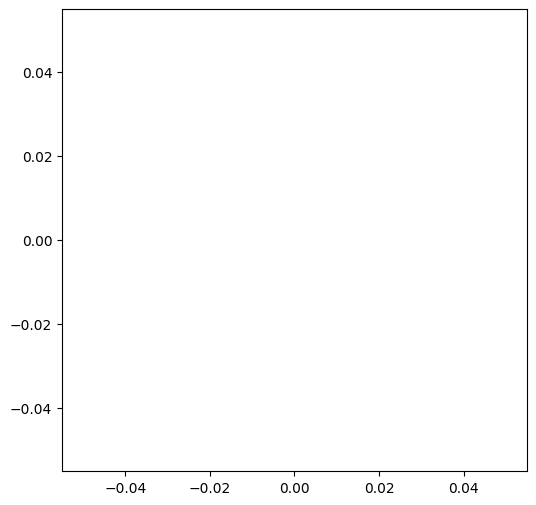

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
eye_df = eye_df.iloc[::10, :]
# Step 1: Average left/right eye gaze to get one gaze point per timestamp
eye_df['Gaze_X'] = eye_df[['LeftEye_Gaze_X', 'RightEye_Gaze_X']].mean(axis=1)
eye_df['Gaze_Y'] = eye_df[['LeftEye_Gaze_Y', 'RightEye_Gaze_Y']].mean(axis=1)

# Optional: remove NaNs or unrealistic gaze points
eye_df = eye_df.dropna(subset=['Gaze_X', 'Gaze_Y'])
eye_df = eye_df[(eye_df['Gaze_X'].between(-1, 1)) & (eye_df['Gaze_Y'].between(-1, 1))]

# Step 2: Plot gaze points for each condition
conditions = eye_df['Condition'].unique()

for cond in conditions:
    data_cond = eye_df[eye_df['Condition'] == cond]

    plt.figure(figsize=(6, 6))
    sns.kdeplot(
        data=data_cond, x='Gaze_X', y='Gaze_Y',
        cmap="rocket", fill=True, bw_adjust=0.1, thresh=0.05, levels=100
    )
    plt.scatter(data_cond['Gaze_X'], data_cond['Gaze_Y'], alpha=0.05, s=2, color='black')
    plt.title(f'Gaze Focus Map - Condition: {cond}')
    plt.xlabel('Gaze X')
    plt.ylabel('Gaze Y')
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.gca().invert_yaxis()  # Optional: invert Y for screen-like orientation
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure Gaze_X and Gaze_Y are computed
eye_df['Gaze_X'] = eye_df[['LeftEye_Gaze_X', 'RightEye_Gaze_X']].mean(axis=1)
eye_df['Gaze_Y'] = eye_df[['LeftEye_Gaze_Y', 'RightEye_Gaze_Y']].mean(axis=1)

# Filter valid gaze data
eye_df = eye_df.dropna(subset=['Gaze_X', 'Gaze_Y'])
eye_df = eye_df[(eye_df['Gaze_X'].between(-1, 1)) & (eye_df['Gaze_Y'].between(-1, 1))]

# Get unique conditions
conditions = eye_df['Condition'].unique()

# Plot gaze heatmaps per participant and condition
for pid in eye_df['participant'].unique():
    data_p = eye_df[eye_df['participant'] == pid]

    plt.figure(figsize=(10, 3))
    plotted_any = False  # Flag to track if anything was plotted

    for i, cond in enumerate(conditions):
        try:
            data_c = data_p[data_p['Condition'] == cond]

            # Check if there's enough data to plot
            if data_c.shape[0] < 50:
                continue

            plt.subplot(1, len(conditions), i + 1)
            sns.kdeplot(
                data=data_c,
                x='Gaze_X',
                y='Gaze_Y',
                cmap="mako",
                fill=True,
                bw_adjust=0.15
            )
            plt.title(f'P{pid} - {cond}')
            plt.xlim(-1, 1)
            plt.ylim(-1, 1)
            plt.gca().invert_yaxis()
            plotted_any = True

        except Exception as e:
            continue  # Ignore and skip to the next plot

    if plotted_any:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()


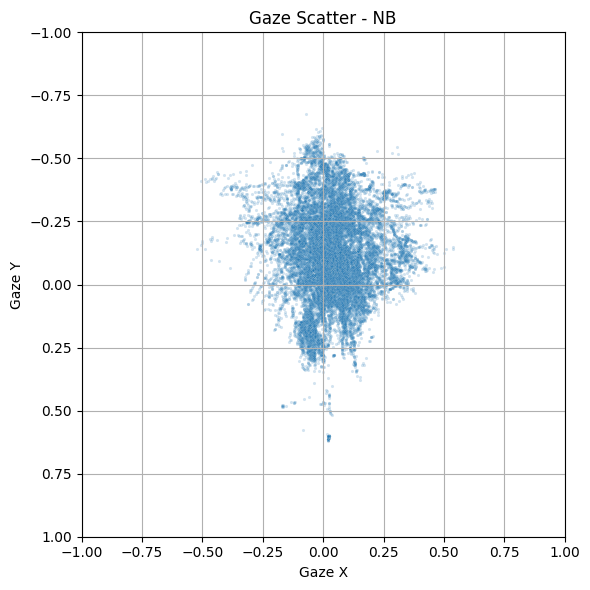

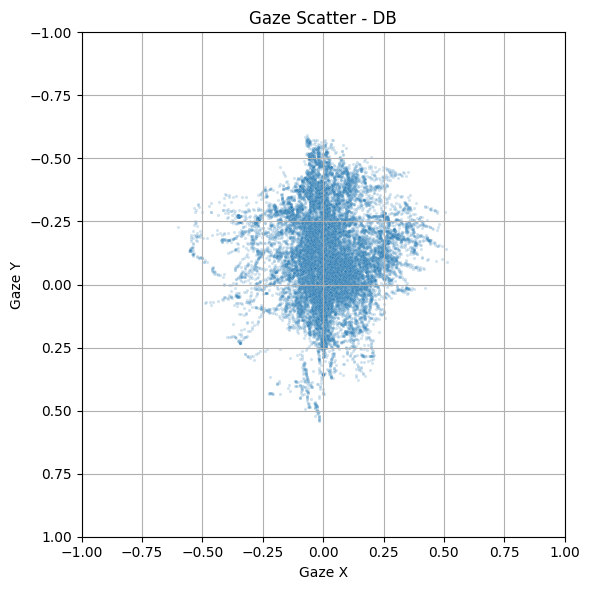

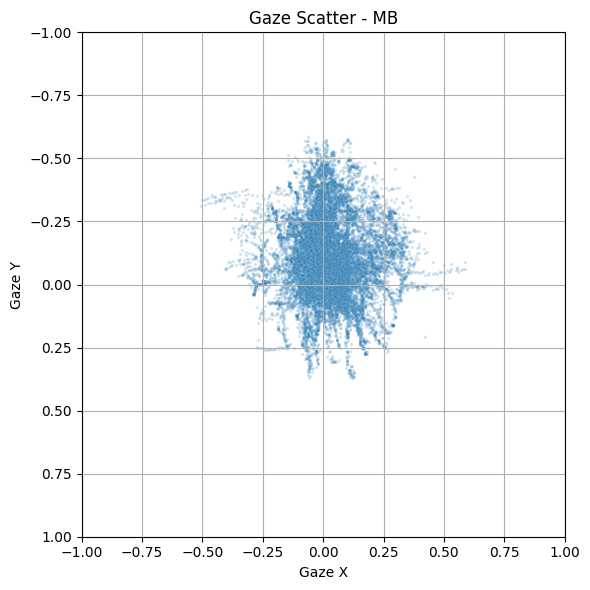

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average gaze per timestamp
eye_df['Gaze_X'] = eye_df[['LeftEye_Gaze_X', 'RightEye_Gaze_X']].mean(axis=1)
eye_df['Gaze_Y'] = eye_df[['LeftEye_Gaze_Y', 'RightEye_Gaze_Y']].mean(axis=1)

# Clean data
eye_df = eye_df.dropna(subset=['Gaze_X', 'Gaze_Y'])
eye_df = eye_df[(eye_df['Gaze_X'].between(-1, 1)) & (eye_df['Gaze_Y'].between(-1, 1))]

# Downsample to make plotting faster (e.g., take every 20th row)
eye_df_sampled = eye_df.iloc[::10, :]

# Plot scatter for each condition
for cond in eye_df_sampled['Condition'].unique():
    data = eye_df_sampled[eye_df_sampled['Condition'] == cond]

    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=data, x='Gaze_X', y='Gaze_Y', alpha=0.2, s=5)
    plt.title(f'Gaze Scatter - {cond}')
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.gca().invert_yaxis()
    plt.xlabel('Gaze X')
    plt.ylabel('Gaze Y')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Correlation

In [16]:
import pandas as pd
from scipy.stats import pearsonr
pre_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores.csv")
post_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores.csv")
pre_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores_ksu.csv")
post_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores_ksu.csv")

pre_ssq = pd.concat([pre_df1, pre_df2], axis=0)
post_ssq= pd.concat([post_df1, post_df2], axis=0)
post_ssq.drop(columns=['Name'], inplace=True)
pre_ssq.dropna(inplace=True)
post_ssq.dropna(inplace=True)
# Merge on Participant + Condition (and Session if consistent)
# Example: load your pre and post DataFrames
# pre_ssq = pd.read_csv("pre.csv")
# post_ssq = pd.read_csv("post.csv")

# Map conditions to numeric blur levels
blur_map = {"NB": 0, "DB": 1, "MB": 2}
pre_ssq["blur_level"] = pre_ssq["Condition"].map(blur_map)
post_ssq["blur_level"] = post_ssq["Condition"].map(blur_map)

# Merge on Participant + Condition (and Session if consistent)
merged = pd.merge(
    post_ssq,
    pre_ssq,
    on=["Participant", "Condition", "Session"],
    suffixes=("_post", "_pre")
)

# Compute SSQ change (Post – Pre) for each subscale
for col in ["Nausea", "Oculomotor", "Disorientation", "Total"]:
    merged[f"{col}_change"] = merged[f"{col}_post"] - merged[f"{col}_pre"]

# Keep only useful columns
ssq_change = merged[[
    "Participant", "blur_level_post",
    "Nausea_change", "Oculomotor_change", "Disorientation_change", "Total_change"
]].rename(columns={"blur_level_post": "blur_level"})

print(ssq_change.head())



# Aggregate to make sure each Participant-blur_level is unique
agg_change = ssq_change.groupby(["Participant", "blur_level"]).mean().reset_index()

# Pivot now works
df_pivot = agg_change.pivot(index='Participant', columns='blur_level', values='Nausea_change')

# Center each participant (remove between-subject mean)
df_centered = df_pivot.sub(df_pivot.mean(axis=1), axis=0)

# Correlation between two blur levels
from scipy.stats import pearsonr
r, p = pearsonr(df_centered[1], df_centered[2])
print(f"Within-subject correlation (level 1 vs 2): r={r:.3f}, p={p:.3f}")


   Participant  blur_level  Nausea_change  Oculomotor_change  \
0           16           0          38.16              30.32   
1           16           1          -9.54              22.74   
2           17           2           9.54              15.16   
3           17           1         114.48              30.32   
4           18           1           0.00               0.00   

   Disorientation_change  Total_change  
0                  41.76         41.14  
1                  27.84         14.96  
2                  41.76         22.44  
3                 111.36         89.76  
4                   0.00          0.00  
Within-subject correlation (level 1 vs 2): r=nan, p=nan


In [18]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import itertools

# ---------- Safe correlation helper ----------
def safe_corr(x, y):
    # Drop NaNs
    mask = (~pd.isna(x)) & (~pd.isna(y))
    x, y = x[mask], y[mask]

    # Need at least 2 samples, and non-zero variance
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan, len(x)
    r, p = pearsonr(x, y)
    return r, p, len(x)

# ---------- WSC computation ----------
def wscorr_matrix(df, subscale):
    # Aggregate to unique (Participant, blur_level)
    agg_df = df.groupby(["Participant", "blur_level"]).mean().reset_index()

    # Pivot: wide format
    wide = agg_df.pivot(index="Participant", columns="blur_level", values=subscale)

    # Center each participant (remove between-subject mean)
    wide_centered = wide.sub(wide.mean(axis=1), axis=0)

    results = []
    levels = wide_centered.columns

    for a, b in itertools.combinations(levels, 2):
        r, p, n = safe_corr(wide_centered[a], wide_centered[b])
        results.append({
            "subscale": subscale,
            "level_a": a,
            "level_b": b,
            "r": r,
            "p": p,
            "n_pairs": n
        })

    return pd.DataFrame(results)

# ---------- Run for all three subscales ----------
subscales = ["Nausea_change", "Oculomotor_change", "Disorientation_change"]

all_results = pd.concat([wscorr_matrix(ssq_change, s) for s in subscales], ignore_index=True)

print(all_results)


                subscale  level_a  level_b         r             p  n_pairs
0          Nausea_change        0        1 -0.828314  1.481443e-09       34
1          Nausea_change        0        2 -0.381159  3.437904e-02       31
2          Nausea_change        1        2 -0.803391  3.112182e-08       32
3      Oculomotor_change        0        1 -0.783888  4.175950e-08       34
4      Oculomotor_change        0        2 -0.260356  1.571974e-01       31
5      Oculomotor_change        1        2 -0.446003  1.051272e-02       32
6  Disorientation_change        0        1 -0.779816  5.453425e-08       34
7  Disorientation_change        0        2 -0.262952  1.529510e-01       31
8  Disorientation_change        1        2 -0.575023  5.762551e-04       32


subscale → SSQ subscale (Nausea, Oculomotor, Disorientation).

level_a / level_b → blur levels being compared (0 = NB, 1 = DB, 2 = MB).

r → within-subject correlation coefficient. Negative means inverse relation (participants who get worse in one level tend to improve in the other).

p → significance level. Small values (<0.05) mean the correlation is statistically reliable.

n_pairs → how many participants had usable data for that comparison

Nausea_change

0 vs 1 → r = -0.83, p < 0.000000001 → very strong negative correlation
→ People who had nausea reduction in NB tended to have nausea increase in DB, and vice versa.

0 vs 2 → r = -0.38, p ≈ 0.03 → moderate negative correlation.

1 vs 2 → r = -0.80, p < 0.00000001 → strong negative correlation.
👉 Suggests blur level effects are inconsistent within participants: improvement at one blur often means worsening at another.

Oculomotor_change

0 vs 1 → r = -0.78, p < 0.0000001 → strong negative relation.

0 vs 2 → r = -0.26, p = 0.15 → weak, not significant.

1 vs 2 → r = -0.45, p = 0.01 → moderate negative.
👉 Again, DB is opposite to NB for most participants.

Disorientation_change

0 vs 1 → r = -0.78, p < 0.0000001 → strong negative.

0 vs 2 → r = -0.26, p = 0.15 → weak, not significant.

1 vs 2 → r = -0.58, p = 0.0006 → strong negative.
👉 Similar story: DB vs MB also diverge.